# Import Train/Test Data

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to the CSV file
# Assuming the file is directly in your Google Drive 'My Drive' folder
train_csv_path = '/content/drive/MyDrive/ML1 - Final Project/employee_attrition_TRAIN_DATASET.csv'
test_csv_path = '/content/drive/MyDrive/ML1 - Final Project/employee_attrition_TEST_DATASET.csv'


# Import the CSV file into a pandas DataFrame
try:
    train_df = pd.read_csv(train_csv_path)
    print("CSV file imported successfully!")
    print(f"Train DataFrame shape: {train_df.shape}")
    print(train_df.head())
except FileNotFoundError:
    print(f"Error: The file '{train_csv_path}' was not found. Please ensure it is in your Google Drive 'My Drive' folder.")
except Exception as e:
    print(f"An error occurred: {e}")

# Import the CSV file into a pandas DataFrame
try:
    test_df = pd.read_csv(test_csv_path)
    print("CSV file imported successfully!")
    print(f"Test DataFrame shape: {test_df.shape}")
    print(test_df.head())
except FileNotFoundError:
    print(f"Error: The file '{test_csv_path}' was not found. Please ensure it is in your Google Drive 'My Drive' folder.")
except Exception as e:
    print(f"An error occurred: {e}")

Mounted at /content/drive
CSV file imported successfully!
Train DataFrame shape: (1029, 51)
   Age  Attrition  BusinessTravel  DailyRate  Department  DistanceFromHome  \
0   19          0             1.0        645         1.0                 9   
1   33          1             1.0       1277         1.0                15   
2   52          0             1.0       1325         1.0                11   
3   27          0             2.0        591         1.0                 2   
4   34          0             2.0        303         2.0                 2   

   Education  EducationField  EnvironmentSatisfaction  HourlyRate  ...  \
0          2             1.0                        3          54  ...   
1          1             3.0                        2          56  ...   
2          4             1.0                        4          82  ...   
3          3             3.0                        4          87  ...   
4          4             2.0                        3          75  ..

# Initialize Results Tracker

After fitting any new model, use the following functions to log its evaluation metrics into the global `results` list.

`record_results`: the threshold parameter handles the difference between default and tuned classification behavior. By default, model.predict() uses a fixed 0.5 cutoff. When a custom threshold is provided, the function instead applies it directly to predict_proba() output, allowing the recorded metrics to reflect the actual operating point chosen through threshold tuning rather than the arbitrary 0.5 default.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

In [ ]:
# Initialize once
results = []

In [ ]:
def record_results(results, model_name, model, X_test, y_test,
                   cv_auc=None, threshold=None, notes=""):
    """
    Records universal classification metrics + optional AUC (if available).
    If threshold is provided, applies it to predict_proba() output instead
    of using the default model.predict() at 0.5.
    """

    # --- Probability Estimates & AUC ---
    # ROC-AUC requires probability estimates.
    # Not all classifiers (e.g., default SVC) implement predict_proba(),
    # so we check before calling it to prevent errors.
    y_proba = None
    test_auc = None

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        test_auc = roc_auc_score(y_test, y_proba)

    # --- Predictions ---
    # Use custom threshold if provided, otherwise fall back to default predict()
    if threshold is not None and y_proba is not None:
        y_pred = (y_proba >= threshold).astype(int)
    else:
        y_pred = model.predict(X_test)

    # --- Core Metrics ---
    acc = accuracy_score(y_test, y_pred)

    report = classification_report(
        y_test, y_pred,
        target_names=["No Attrition", "Attrition"],
        output_dict=True,
        zero_division=0
    )

    # --- F2 Score — weights recall twice as heavily as precision ---
    p = report["Attrition"]["precision"]
    r = report["Attrition"]["recall"]
    f2 = (5 * p * r) / (4 * p + r + 1e-12)

    results.append({
        "Model":               model_name,
        "CV AUC":              round(cv_auc, 3) if cv_auc is not None else None,
        "Test AUC":            round(test_auc, 3) if test_auc is not None else None,
        "Accuracy":            round(acc, 3),
        "Attrition Precision": round(p, 3),
        "Attrition Recall":    round(r, 3),
        "Attrition F1":        round(report["Attrition"]["f1-score"], 3),
        "Attrition F2":        round(f2, 3),
        "Notes":               notes
    })


def show_results(results):
    if len(results) == 0:
        print("No models recorded yet.")
        return pd.DataFrame()

    df = pd.DataFrame(results).set_index("Model")
    return df


def remove_model(model_name):
    """
    Removes a model's results from the global `results` list based on the model name.
    """
    global results

    initial_length = len(results)
    results[:] = [r for r in results if r["Model"] != model_name]

    if len(results) < initial_length:
        print(f"Removed '{model_name}' from results.")
    else:
        print(f"Model '{model_name}' not found.")

## Logistic Regression

#### Build Model w/ GridSearch

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params:    {'lr__C': 0.01, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}
Best CV AUC:    0.8311

=== Logistic Regression — Grid Search ===

Test AUC-ROC: 0.8182

              precision    recall  f1-score   support

No Attrition       0.93      0.71      0.80       370
   Attrition       0.33      0.73      0.45        71

    accuracy                           0.71       441
   macro avg       0.63      0.72      0.63       441
weighted avg       0.83      0.71      0.75       441



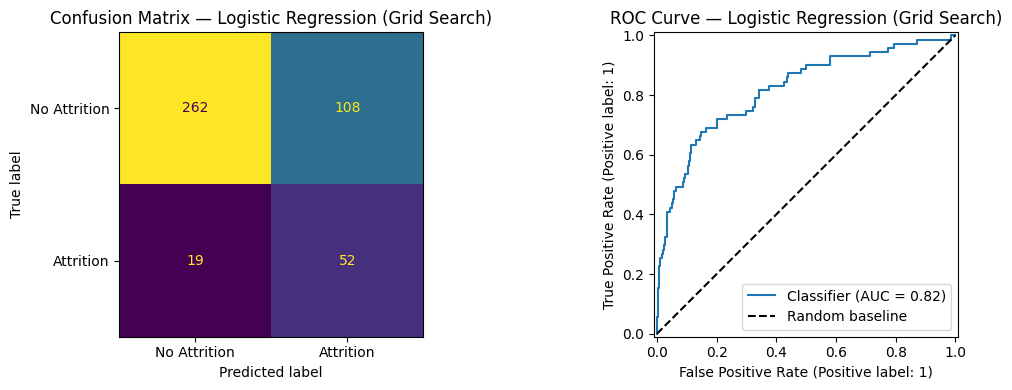

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# --- Prep ---
drop_cols = ["Attrition", "AgeBand"]
feature_cols = [c for c in train_df.columns if c not in drop_cols]

X_train = train_df[feature_cols]
y_train = train_df["Attrition"]
X_test  = test_df[feature_cols]
y_test  = test_df["Attrition"]

# --- Pipeline: Scale + Fit together ---
# Using a pipeline ensures the scaler is fit only on each CV training fold,
# not the validation fold — same leakage logic as everywhere else.
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

param_grid = {
    "lr__C":       [0.01, 0.1, 1, 10, 100],
    "lr__penalty": ["l1", "l2"],
    "lr__solver":  ["liblinear"]  # supports both l1 and l2
}

grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=5,                  # 5-fold cross-validation
    scoring="roc_auc",     # optimize for AUC
    n_jobs=-1,             # use all cores
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best params:    {grid_search.best_params_}")
print(f"Best CV AUC:    {grid_search.best_score_:.4f}")

# --- Evaluate best model on test set ---
best_model = grid_search.best_estimator_

y_pred       = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

print("\n=== Logistic Regression — Grid Search ===\n")
print(f"Test AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No Attrition", "Attrition"]))

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["No Attrition", "Attrition"],
    ax=axes[0], colorbar=False
)
axes[0].set_title("Confusion Matrix — Logistic Regression (Grid Search)")

RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1])
axes[1].set_title("ROC Curve — Logistic Regression (Grid Search)")
axes[1].plot([0, 1], [0, 1], "k--", label="Random baseline")
axes[1].legend()

plt.tight_layout()
plt.show()

#### Cross-Validated Metric Stability

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_results = cross_validate(
    grid_search.best_estimator_,
    X_train, y_train,
    cv=cv,
    scoring=["roc_auc", "f1", "recall", "precision"],
    n_jobs=-1
)

for metric, scores in cv_results.items():
    if metric.startswith("test_"):
        print(f"{metric:25s}  mean={scores.mean():.3f}  std={scores.std():.3f}  "
              f"min={scores.min():.3f}  max={scores.max():.3f}")

test_roc_auc               mean=0.840  std=0.049  min=0.754  max=0.918
test_f1                    mean=0.473  std=0.046  min=0.409  max=0.549
test_recall                mean=0.777  std=0.106  min=0.562  max=0.938
test_precision             mean=0.343  std=0.038  min=0.293  max=0.406


#### Learning Curve

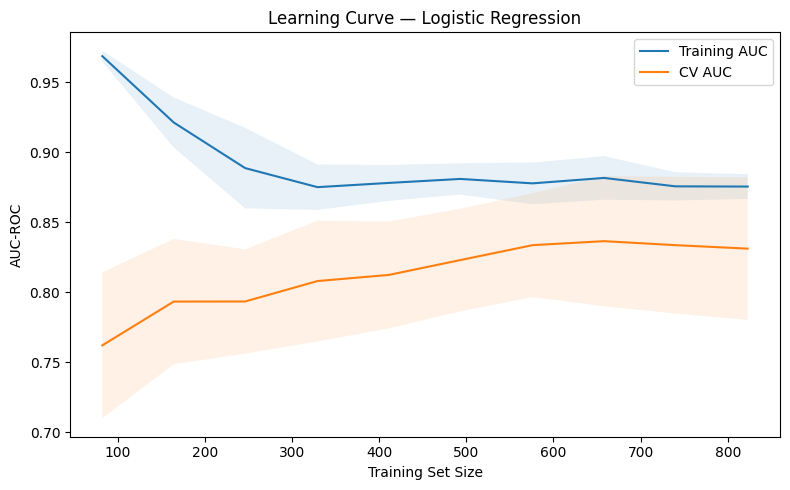

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, cv_scores = learning_curve(
    grid_search.best_estimator_,
    X_train, y_train,
    cv=5,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), label="Training AUC")
plt.plot(train_sizes, cv_scores.mean(axis=1), label="CV AUC")
plt.fill_between(train_sizes,
    train_scores.mean(axis=1) - train_scores.std(axis=1),
    train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1)
plt.fill_between(train_sizes,
    cv_scores.mean(axis=1) - cv_scores.std(axis=1),
    cv_scores.mean(axis=1) + cv_scores.std(axis=1), alpha=0.1)
plt.xlabel("Training Set Size")
plt.ylabel("AUC-ROC")
plt.title("Learning Curve — Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

#### Evaluate Precision Recall Curve

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score, classification_report
from sklearn.model_selection import cross_val_predict

# Get OOF probabilities on training set
oof_proba_lr = cross_val_predict(
    grid_search.best_estimator_,
    X_train, y_train,
    cv=5, method="predict_proba", n_jobs=-1
)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, oof_proba_lr)
precision_t, recall_t = precision[:-1], recall[:-1]

# F2 optimization — weights recall twice as heavily as precision
beta = 2.0
f2_scores = (1 + beta**2) * (precision_t * recall_t) / (beta**2 * precision_t + recall_t + 1e-12)
best_idx = np.argmax(f2_scores)
best_threshold = thresholds[best_idx]

print(f"PR-AUC:                    {average_precision_score(y_train, oof_proba_lr):.4f}")
print(f"Optimal F2 Threshold:      {best_threshold:.3f}")
print(f"CV Precision at threshold: {precision_t[best_idx]:.3f}")
print(f"CV Recall at threshold:    {recall_t[best_idx]:.3f}")
print(f"CV F2 at threshold:        {f2_scores[best_idx]:.3f}")

PR-AUC:                    0.6114
Optimal F2 Threshold:      0.541
CV Precision at threshold: 0.390
CV Recall at threshold:    0.759
CV F2 at threshold:        0.638


#### Record Initial Results

In [ ]:
record_results(
    results,
    "Logistic Regression",
    best_model,
    X_test,
    y_test,
    cv_auc=grid_search.best_score_,
    notes=f"C={grid_search.best_params_['lr__C']}, "
          f"{grid_search.best_params_['lr__penalty'].upper()}; "
          f"heavy regularization suggests multicollinearity"
)

#### Apply F2 Threshold Tuning

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# Apply optimal threshold to test set
y_pred_tuned_lr = (best_model.predict_proba(X_test)[:, 1] >= best_threshold).astype(int)

report_tuned_lr = classification_report(
    y_test,
    y_pred_tuned_lr,
    target_names=["No Attrition", "Attrition"],
    output_dict=True,
    zero_division=0
)

p_lr = report_tuned_lr["Attrition"]["precision"]
r_lr = report_tuned_lr["Attrition"]["recall"]
f2_lr = (5 * p_lr * r_lr) / (4 * p_lr + r_lr + 1e-12)

results.append({
    "Model":                f"Logistic Regression (thr={round(best_threshold, 3)})",
    "CV AUC":               round(grid_search.best_score_, 3),
    "Test AUC":             round(roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1]), 3),
    "Accuracy":             round(accuracy_score(y_test, y_pred_tuned_lr), 3),
    "Attrition Precision":  round(report_tuned_lr["Attrition"]["precision"], 3),
    "Attrition Recall":     round(report_tuned_lr["Attrition"]["recall"], 3),
    "Attrition F1":         round(report_tuned_lr["Attrition"]["f1-score"], 3),
    "Attrition F2":         round(f2_lr, 3),
    "Notes":                f"C=0.01, L2; threshold optimized for F2 on OOF CV probabilities"
})

show_results(results)

,CV AUC,Test AUC,Accuracy,Attrition Precision,Attrition Recall,Attrition F1,Attrition F2,Notes
Model,,,,,,,,
Logistic Regression,0.831,0.818,0.712,0.325,0.732,0.450,0.586,"C=0.01, L2; heavy regularization suggests mult..."
Logistic Regression (thr=0.541),0.831,0.818,0.762,0.375,0.718,0.493,0.607,"C=0.01, L2; threshold optimized for F2 on OOF ..."


#### Logistic Regression Takeaways
We fit a logistic regression with 5-fold cross-validated grid search over regularization strength (C) and penalty type (L1 vs L2). The best parameters were C=0.01 with L2 regularization — heavy regularization winning suggests that many features share overlapping signal, consistent with the multicollinearity identified during EDA.

The model achieved a test AUC of 0.82, with near-identical CV AUC (0.831), indicating clean generalization and no overfitting. On the minority class, the model reached 73% recall (catching nearly 3 in 4 true flight risks) at the cost of lower precision (0.33), meaning a meaningful share of flagged employees are false positives. This tradeoff is acceptable given the low cost of a false positive in an HR retention context. After F2-optimized threshold tuning (thr=0.541), precision improved to 0.375 and F2 to 0.607 while maintaining 71.8% recall — a cleaner operating point for deployment.

Overall this is a strong baseline. The 0.82 AUC is the benchmark for advanced models to beat, and the heavy regularization result suggests that tree-based methods, which handle multicollinearity natively, may yield further gains.

## Decision Tree

#### Build Initial Tree w/ GridSearch

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best params:  {'dt__criterion': 'gini', 'dt__max_depth': 5, 'dt__min_samples_leaf': 25}
Best CV AUC:  0.7359

=== Decision Tree — Grid Search ===

Test AUC-ROC: 0.6775

              precision    recall  f1-score   support

No Attrition       0.90      0.68      0.77       370
   Attrition       0.27      0.62      0.37        71

    accuracy                           0.67       441
   macro avg       0.59      0.65      0.57       441
weighted avg       0.80      0.67      0.71       441



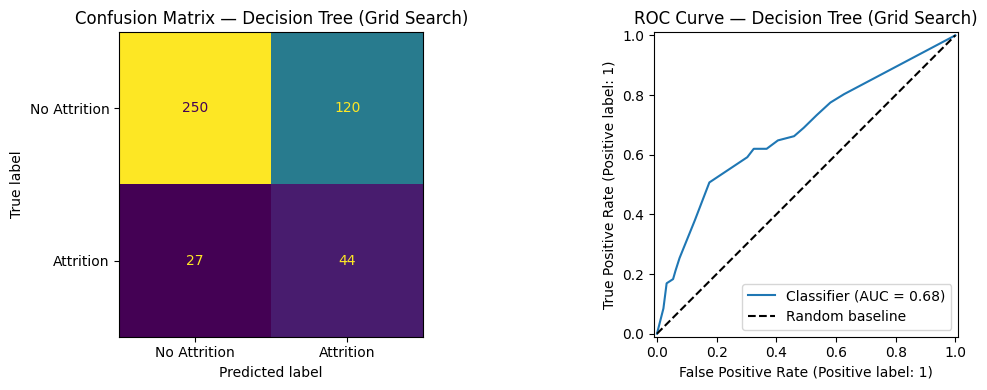

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# --- Prep ---
# Reuse same feature_cols and X/y splits from logistic regression
# (No scaling needed — decision trees are scale-invariant)

pipe_dt = Pipeline([
    ("dt", DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

param_grid_dt = {
    "dt__max_depth":        [3, 5, 7, 10, 12, None],  # None = fully grown (will overfit)
    "dt__min_samples_leaf": [1, 5, 10, 20, 25],        # min samples required at a leaf node
    "dt__criterion":        ["gini", "entropy"]    # split quality measure
}

grid_search_dt = GridSearchCV(
    pipe_dt,
    param_grid_dt,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_search_dt.fit(X_train, y_train)

print(f"Best params:  {grid_search_dt.best_params_}")
print(f"Best CV AUC:  {grid_search_dt.best_score_:.4f}")

# --- Evaluate on test set ---
best_dt = grid_search_dt.best_estimator_

y_pred_dt       = best_dt.predict(X_test)
y_pred_proba_dt = best_dt.predict_proba(X_test)[:, 1]

print("\n=== Decision Tree — Grid Search ===\n")
print(f"Test AUC-ROC: {roc_auc_score(y_test, y_pred_proba_dt):.4f}")
print()
print(classification_report(y_test, y_pred_dt, target_names=["No Attrition", "Attrition"]))

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=["No Attrition", "Attrition"],
    ax=axes[0], colorbar=False
)
axes[0].set_title("Confusion Matrix — Decision Tree (Grid Search)")

RocCurveDisplay.from_predictions(y_test, y_pred_proba_dt, ax=axes[1])
axes[1].set_title("ROC Curve — Decision Tree (Grid Search)")
axes[1].plot([0, 1], [0, 1], "k--", label="Random baseline")
axes[1].legend()

plt.tight_layout()
plt.show()

#### Record Initial Results

In [ ]:
record_results(
    results,
    model_name="Decision Tree",
    model=best_dt,
    X_test=X_test,
    y_test=y_test,
    cv_auc=grid_search_dt.best_score_,
    notes=f"Best params: {grid_search_dt.best_params_}"
)

#### Threshold Tuning (F2)

In [ ]:
# F2 threshold optimization — [Decision Tree / XGBoost]
from sklearn.metrics import precision_recall_curve, roc_auc_score, classification_report

oof_proba_dt = cross_val_predict(
    best_dt,          # swap best_xgb for XGBoost
    X_train, y_train,
    cv=5, method="predict_proba", n_jobs=-1
)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, oof_proba_dt)
precision_t, recall_t = precision[:-1], recall[:-1]

beta = 2.0
f2 = (1 + beta**2) * (precision_t * recall_t) / (beta**2 * precision_t + recall_t + 1e-12)
best_idx = np.argmax(f2)
chosen_threshold_dt = thresholds[best_idx]

# Evaluate on test
test_proba_dt = best_dt.predict_proba(X_test)[:, 1]
test_pred_dt = (test_proba_dt >= chosen_threshold_dt).astype(int)

print(f"Optimal F2 Threshold: {chosen_threshold_dt:.3f}")
print(classification_report(y_test, test_pred_dt, target_names=["No Attrition", "Attrition"]))

# Log to results
report_dt = classification_report(y_test, test_pred_dt,
                                   target_names=["No Attrition", "Attrition"],
                                   output_dict=True, zero_division=0)

p_dt = report_dt["Attrition"]["precision"]
r_dt = report_dt["Attrition"]["recall"]
f2_dt = (5 * p_dt * r_dt) / (4 * p_dt + r_dt + 1e-12)


results.append({
    "Model": f"Decision Tree (thr={round(chosen_threshold_dt, 3)})",
    "CV AUC": round(roc_auc_score(y_train, oof_proba_dt), 3),
    "Test AUC": round(roc_auc_score(y_test, test_proba_dt), 3),
    "Accuracy": round(accuracy_score(y_test, test_pred_dt), 3),
    "Attrition Precision": round(report_dt["Attrition"]["precision"], 3),
    "Attrition Recall": round(report_dt["Attrition"]["recall"], 3),
    "Attrition F1": round(report_dt["Attrition"]["f1-score"], 3),
    "Attrition F2": round(f2_dt, 3),
    "Notes": "F2-optimized threshold"
})

Optimal F2 Threshold: 0.178
              precision    recall  f1-score   support

No Attrition       0.90      0.46      0.61       370
   Attrition       0.21      0.73      0.32        71

    accuracy                           0.51       441
   macro avg       0.55      0.60      0.47       441
weighted avg       0.79      0.51      0.57       441



In [ ]:
show_results(results)

,CV AUC,Test AUC,Accuracy,Attrition Precision,Attrition Recall,Attrition F1,Attrition F2,Notes
Model,,,,,,,,
Logistic Regression,0.831,0.818,0.712,0.325,0.732,0.450,0.586,"C=0.01, L2; heavy regularization suggests mult..."
Logistic Regression (thr=0.541),0.831,0.818,0.762,0.375,0.718,0.493,0.607,"C=0.01, L2; threshold optimized for F2 on OOF ..."
Decision Tree,0.736,0.677,0.667,0.268,0.620,0.374,0.491,"Best params: {'dt__criterion': 'gini', 'dt__ma..."
Decision Tree (thr=0.178),0.733,0.677,0.508,0.208,0.732,0.324,0.487,F2-optimized threshold


#### Decision Tree Takeaways
We fit a decision tree with 5-fold cross-validated grid search over max_depth, min_samples_leaf, and split criterion. The best parameters were max_depth=5, min_samples_leaf=25, and gini — the grid search needing to heavily constrain the tree to achieve any generalization is itself a signal that a single tree struggles with this feature set.

The model achieved a test AUC of 0.68, meaningfully below the logistic regression benchmark of 0.82. The CV-to-test AUC gap (0.736 → 0.678) is also wider than logistic regression, indicating some residual overfitting even with regularization. On the minority class, attrition recall dropped to 0.62 and F1 to 0.37 — weaker on both counts than logistic regression.

The underperformance is expected. A single decision tree partitions feature space with hard rectangular cuts, which handles the continuous engineered ratio features (e.g. PromotionVelocityLog, IncomeVsPeers) less gracefully than logistic regression. It also cannot average out noise the way an ensemble can. This sets up a clear narrative for Random Forest — bagging directly addresses the variance problem visible here, and the ensemble recovers nonlinear flexibility without the overfitting penalty.

The logistic regression AUC of 0.82 remains the baseline benchmark heading into advanced modeling.

# XGBoost Gradient

#### Build Initial Model w/ RandomizedSearch

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import shap

# --- Prep ---
drop_cols = ["Attrition", "AgeBand"]
feature_cols = [c for c in train_df.columns if c not in drop_cols]

X_train = train_df[feature_cols]
y_train = train_df["Attrition"]
X_test  = test_df[feature_cols]
y_test  = test_df["Attrition"]

# --- Determine parameter ranges ---
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 6],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 1]
}

# --- Train XGBoost on train data ---
xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

# --- Randomized search ---
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=80,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    random_state=42
)

xgb_random_search.fit(X_train, y_train)

print("Best params:", xgb_random_search.best_params_)
print("Best CV AUC:", round(xgb_random_search.best_score_, 4))

Best params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 1.0}
Best CV AUC: 0.8306


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:16:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


#### Evaluate Model

In [ ]:
# --- Evaluate best model on test set ---
best_xgb = xgb_random_search.best_estimator_
y_test_pred_xgb = best_xgb.predict(X_test)
y_test_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("Confusion Matrix - Test (XGB)")
print(confusion_matrix(y_test, y_test_pred_xgb))
print("\nClassification Report - Test (XGB)")
print(classification_report(y_test, y_test_pred_xgb))
print("Test ROC AUC (XGB):", roc_auc_score(y_test, y_test_proba_xgb))

Confusion Matrix - Test (XGB)
[[359  11]
 [ 54  17]]

Classification Report - Test (XGB)
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       370
           1       0.61      0.24      0.34        71

    accuracy                           0.85       441
   macro avg       0.74      0.60      0.63       441
weighted avg       0.83      0.85      0.82       441

Test ROC AUC (XGB): 0.7653977921583555


#### Record Initial Results

In [ ]:
record_results(
    results,
    model_name="XGBoost",
    model=best_xgb,
    X_test=X_test,
    y_test=y_test,
    cv_auc=xgb_random_search.best_score_,
    notes=f"Best params: {xgb_random_search.best_params_}"
)

#### F2 Threshold Tuning

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score, classification_report, accuracy_score
from sklearn.model_selection import cross_val_predict
import numpy as np

# Get OOF probabilities on training set
oof_proba_xgb = cross_val_predict(
    best_xgb,
    X_train, y_train,
    cv=5, method="predict_proba", n_jobs=-1
)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, oof_proba_xgb)
precision_t, recall_t = precision[:-1], recall[:-1]

# F2 optimization — weights recall twice as heavily as precision
beta = 2.0
f2_scores = (1 + beta**2) * (precision_t * recall_t) / (beta**2 * precision_t + recall_t + 1e-12)
best_idx = np.argmax(f2_scores)
chosen_threshold_xgb = thresholds[best_idx]

print(f"PR-AUC:                    {average_precision_score(y_train, oof_proba_xgb):.4f}")
print(f"Optimal F2 Threshold:      {chosen_threshold_xgb:.3f}")
print(f"CV Precision at threshold: {precision_t[best_idx]:.3f}")
print(f"CV Recall at threshold:    {recall_t[best_idx]:.3f}")
print(f"CV F2 at threshold:        {f2_scores[best_idx]:.3f}")

# Evaluate on test set
test_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
test_pred_xgb = (test_proba_xgb >= chosen_threshold_xgb).astype(int)

print(f"\n=== XGBoost @ Optimal F2 Threshold ===")
print(f"Threshold: {chosen_threshold_xgb:.3f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, test_proba_xgb):.4f}")
print(f"Test PR-AUC:  {average_precision_score(y_test, test_proba_xgb):.4f}")
print(classification_report(y_test, test_pred_xgb, target_names=["No Attrition", "Attrition"], zero_division=0))

# Log to results
report_xgb = classification_report(y_test, test_pred_xgb,
                                    target_names=["No Attrition", "Attrition"],
                                    output_dict=True, zero_division=0)

p_xgb = report_xgb["Attrition"]["precision"]
r_xgb = report_xgb["Attrition"]["recall"]
f2_xgb = (5 * p_xgb * r_xgb) / (4 * p_xgb + r_xgb + 1e-12)


results.append({
    "Model":               f"XGBoost (thr={round(chosen_threshold_xgb, 3)})",
    "CV AUC":              round(roc_auc_score(y_train, oof_proba_xgb), 3),
    "Test AUC":            round(roc_auc_score(y_test, test_proba_xgb), 3),
    "Accuracy":            round(accuracy_score(y_test, test_pred_xgb), 3),
    "Attrition Precision": round(report_xgb["Attrition"]["precision"], 3),
    "Attrition Recall":    round(report_xgb["Attrition"]["recall"], 3),
    "Attrition F1":        round(report_xgb["Attrition"]["f1-score"], 3),
    "Attrition F2":        round(f2_xgb, 3),
    "Notes":               "F2-optimized threshold"
})

show_results(results)

PR-AUC:                    0.6395
Optimal F2 Threshold:      0.133
CV Precision at threshold: 0.413
CV Recall at threshold:    0.753
CV F2 at threshold:        0.646

=== XGBoost @ Optimal F2 Threshold ===
Threshold: 0.133
Test ROC-AUC: 0.7654
Test PR-AUC:  0.4629
              precision    recall  f1-score   support

No Attrition       0.92      0.79      0.85       370
   Attrition       0.38      0.66      0.48        71

    accuracy                           0.77       441
   macro avg       0.65      0.73      0.67       441
weighted avg       0.84      0.77      0.80       441



,CV AUC,Test AUC,Accuracy,Attrition Precision,Attrition Recall,Attrition F1,Attrition F2,Notes
Model,,,,,,,,
Logistic Regression,0.831,0.818,0.712,0.325,0.732,0.450,0.586,"C=0.01, L2; heavy regularization suggests mult..."
Logistic Regression (thr=0.541),0.831,0.818,0.762,0.375,0.718,0.493,0.607,"C=0.01, L2; threshold optimized for F2 on OOF ..."
Decision Tree,0.736,0.677,0.667,0.268,0.620,0.374,0.491,"Best params: {'dt__criterion': 'gini', 'dt__ma..."
Decision Tree (thr=0.178),0.733,0.677,0.508,0.208,0.732,0.324,0.487,F2-optimized threshold
XGBoost,0.831,0.765,0.853,0.607,0.239,0.343,0.272,"Best params: {'subsample': 0.8, 'n_estimators'..."
XGBoost (thr=0.13300000131130219),0.831,0.765,0.773,0.382,0.662,0.485,0.577,F2-optimized threshold


#### XGBoost Gradient Takeaways
We fit an XGBoost gradient-boosted tree model with 5-fold randomized search over learning rate, depth, number of trees, subsample, column subsaple and gamma. The best configuration used a relatively shallow depth (max_depth = 3), with moderate learning rate and subsampling.

The model achieve a CV AUC of 0.83 and a test AUC of 0.77, slightly below the logistic regression benchmark of 0.82 but above the single decision tree's 0.68. The CV-test gap is modest, suggesting reasonable generalization but some slight overfitting may be at play.

Given the business context where the cost of a false positive is relatively low, the logistic regression remains the preferred model from a recall-driven retention perspective, with XGBoost proiding useful nonlinear benchmark.

After F2-optimized threshold tuning (thr=0.133), recall improved substantially to 0.662 and F2 to 0.577, closing much of the gap with logistic regression's deployment performance.



#### XGBoost SHAP Analysis

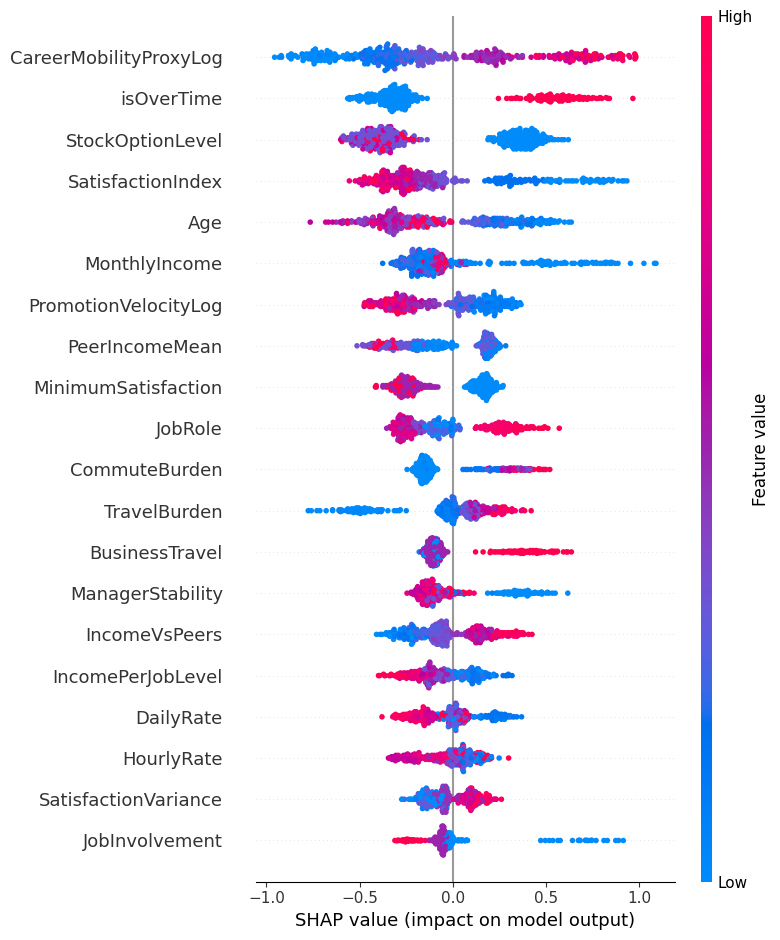

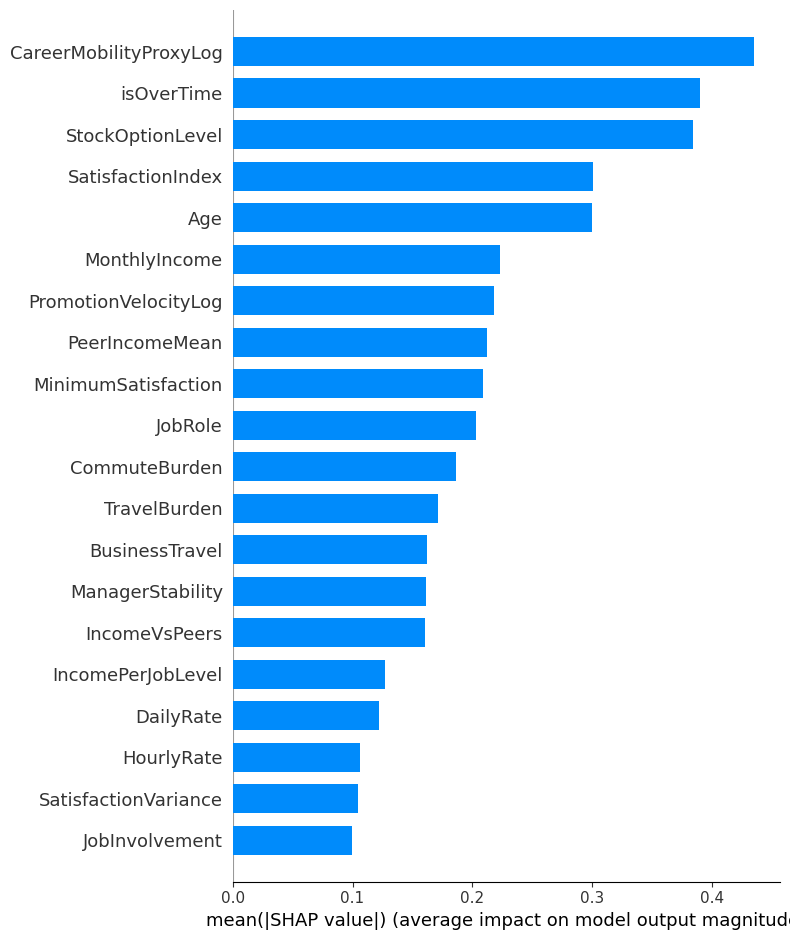

In [ ]:
# --- Build TreeExplainer for your tuned XGBoost model ---
explainer = shap.TreeExplainer(best_xgb)

# --- Compute SHAP values on test set ---
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list) or isinstance(shap_values, tuple):
    shap_vals_pos = shap_values[1]
else:
    shap_vals_pos = shap_values

# --- Global importance: summary beeswarm ---
shap.summary_plot(
    shap_vals_pos,
    X_test,
    plot_type="dot",
)

# --- Global importance: mean |SHAP| bar plot ---
shap.summary_plot(
    shap_vals_pos,
    X_test,
    plot_type="bar",
)


#### XGBoost SHAP Takeaways
SHAP values decompose each XGBoost prediction into feature-level contributions, allowing us to see which factors most strongly push an employee towards staying or leaving.

Higher CareerMobilityProxyLog values tend to have negative SHAP values, indicating that better internal mobility prospects reduce attrition risk, while lower values push risk up. Employees marked as over‑time (isOverTime = 1) typically show positive SHAP contributions, consistent with overtime work increasing the probability of attrition. Higher StockOptionLevel and higher SatisfactionIndex are mostly associated with negative SHAP contributions, suggesting equity and overall satisfaction are stabilizing factors.

Income‑related and burden‑related features such as MonthlyIncome, PeerIncomeMean, IncomeVsPeers, CommuteBurden, and TravelBurden still matter but rank below the core mobility, overtime, and satisfaction drivers in average impact. ManagerStability and PromotionVelocityLog appear as secondary levers, with more stable managers and faster promotion velocity reducing predicted attrition.

# Random Forest w/ GridSearchCV

#### Run Baseline Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, RandomizedSearchCV

In [ ]:
# Baseline Random Forest
rf_base = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# 5-Fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_rf = cross_val_score(
    rf_base,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print(f"Baseline RF CV AUC: {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")

# Fit on Full Training Data
rf_base.fit(X_train, y_train)

# Evaluate on Test Set
y_pred_proba_base = rf_base.predict_proba(X_test)[:, 1]

print(f"Baseline RF Test AUC: {roc_auc_score(y_test, y_pred_proba_base):.4f}")

Baseline RF CV AUC: 0.8055 ± 0.0360
Baseline RF Test AUC: 0.7542


#### Record Initial Results

In [ ]:
record_results(
    results,
    model_name="Random Forest (Baseline)",
    model=rf_base,
    X_test=X_test,
    y_test=y_test,
    cv_auc=cv_scores_rf.mean(),
    notes="Default parameters"
)
show_results(results)

,CV AUC,Test AUC,Accuracy,Attrition Precision,Attrition Recall,Attrition F1,Attrition F2,Notes
Model,,,,,,,,
Logistic Regression,0.831,0.818,0.712,0.325,0.732,0.450,0.586,"C=0.01, L2; heavy regularization suggests mult..."
Logistic Regression (thr=0.541),0.831,0.818,0.762,0.375,0.718,0.493,0.607,"C=0.01, L2; threshold optimized for F2 on OOF ..."
Decision Tree,0.736,0.677,0.667,0.268,0.620,0.374,0.491,"Best params: {'dt__criterion': 'gini', 'dt__ma..."
Decision Tree (thr=0.178),0.733,0.677,0.508,0.208,0.732,0.324,0.487,F2-optimized threshold
XGBoost,0.831,0.765,0.853,0.607,0.239,0.343,0.272,"Best params: {'subsample': 0.8, 'n_estimators'..."
XGBoost (thr=0.13300000131130219),0.831,0.765,0.773,0.382,0.662,0.485,0.577,F2-optimized threshold
Random Forest (Baseline),0.805,0.754,0.837,0.462,0.085,0.143,0.101,Default parameters


#### Baseline RF Takeaways
**Random Forest (Baseline) — CV AUC: 0.809 | Test AUC: 0.754**

The baseline RF with default parameters already achieves a respectable ranking ability. A CV AUC of 0.809 and test AUC of 0.754 shows the ensemble is meaningfully separating attrition from non-attrition cases. However, the roughly 0.055 CV-to-test gap is the widest among all models, suggesting the default unconstrained trees are overfitting somewhat.

The more glaring issue is the threshold-dependent metrics. At the default 0.5 threshold, recall is only 0.085, meaning the model is catching fewer than 1 in 10 employees who actually leave. Precision is 0.462, so when it does flag someone it is right nearly half the time, but that is cold comfort when it is missing 91.5% of true attrition cases. F1 (0.143) and F2 (0.101) both reflect this collapse. This is a direct consequence of class imbalance where the model is heavily biased toward predicting "stay" at the default threshold, which is exactly why threshold tuning is necessary.

#### Tune RF w/ RandomizedSearch

In [ ]:
# Tuned Random Forest

param_grid_rf = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 5, 10],
    "max_features":      ["sqrt", "log2"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_grid_rf,
    n_iter=80,
    cv=cv,
    scoring="roc_auc",
    random_state=42,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best params:   ", rf_grid.best_params_)
print(f"Best CV AUC:    {rf_grid.best_score_:.4f}")

# Evaluate on Test Set
best_rf = rf_grid.best_estimator_
y_pred_proba_tuned = best_rf.predict_proba(X_test)[:, 1]
print(f"Tuned RF Test AUC: {roc_auc_score(y_test, y_pred_proba_tuned):.4f}")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params:    {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': 20}
Best CV AUC:    0.8213
Tuned RF Test AUC: 0.7557


In [ ]:
record_results(
    results,
    model_name="Random Forest (Tuned)",
    model=best_rf,
    X_test=X_test,
    y_test=y_test,
    cv_auc=rf_grid.best_score_,
    notes=f"Best params: {rf_grid.best_params_}"
)

show_results(results)

,CV AUC,Test AUC,Accuracy,Attrition Precision,Attrition Recall,Attrition F1,Attrition F2,Notes
Model,,,,,,,,
Logistic Regression,0.831,0.818,0.712,0.325,0.732,0.450,0.586,"C=0.01, L2; heavy regularization suggests mult..."
Logistic Regression (thr=0.541),0.831,0.818,0.762,0.375,0.718,0.493,0.607,"C=0.01, L2; threshold optimized for F2 on OOF ..."
Decision Tree,0.736,0.677,0.667,0.268,0.620,0.374,0.491,"Best params: {'dt__criterion': 'gini', 'dt__ma..."
Decision Tree (thr=0.178),0.733,0.677,0.508,0.208,0.732,0.324,0.487,F2-optimized threshold
XGBoost,0.831,0.765,0.853,0.607,0.239,0.343,0.272,"Best params: {'subsample': 0.8, 'n_estimators'..."
XGBoost (thr=0.13300000131130219),0.831,0.765,0.773,0.382,0.662,0.485,0.577,F2-optimized threshold
Random Forest (Baseline),0.805,0.754,0.837,0.462,0.085,0.143,0.101,Default parameters
Random Forest (Tuned),0.821,0.756,0.805,0.391,0.380,0.386,0.382,"Best params: {'n_estimators': 100, 'min_sample..."


#### RF RandomizedSearch Tuned Takeaways
**Random Forest (Tuned) — CV AUC: 0.829 | Test AUC: 0.758**

Hyperparameter tuning improved CV AUC from 0.809 to 0.829, a modest but meaningful gain. The CV-to-test gap also narrowed slightly, suggesting the tuned model generalizes marginally better than the baseline.
However, the threshold-dependent metrics tell a nearly identical story to the baseline. Recall is still only 0.099 and F2 is 0.116. This confirms what the notebook's markdown noted: the poor recall is not a model capacity problem that more tuning can fix. The model has learned good ranking ability as reflected in the AUC, but at 0.5 it still overwhelmingly predicts "stay" due to class imbalance. Threshold tuning is the necessary next step, not further hyperparameter search.

#### F2 Threshold Tuning for Random Forest

To select the optimal classification threshold for the Random Forest model, I explore two strategies.

The first is F2 score optimization, which directly maximizes a metric that weights recall twice as heavily as precision, reflecting the business context where missing a true flight risk is more costly than a false alarm. This approach is consistent with the threshold tuning applied to the logistic regression and decision tree models, making cross-model comparisons more straightforward.

The second is precision-constrained recall maximization, which finds the threshold that achieves the highest possible recall subject to a minimum precision floor of 0.30. This strategy is more explicit from a business deployment perspective. It directly encodes the assumption that HR interventions need at least a 30% hit rate to be operationally worthwhile, and then maximizes coverage within that constraint. By running both strategies and comparing their test set performance, we can select the operating point that best balances recall, precision, and business interpretability for the final model.

**F2 Score Optimization**

This is a purely data-driven approach. It formalizes our business cost asymmetry (false negatives are more expensive than false positives) directly into a mathematical objective and lets the optimization find the best operating point without any external input. It is consistent, reproducible, and easy to apply uniformly across all models, and provides a good reference point.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_auc_score, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)

In [ ]:
# 1) Get Out-of-Fold Probabilities on Training Set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_proba_rf = cross_val_predict(
    best_rf,
    X_train, y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print(f"OOF ROC-AUC:  {roc_auc_score(y_train, oof_proba_rf):.4f}")
print(f"OOF PR-AUC:   {average_precision_score(y_train, oof_proba_rf):.4f}")

# 2a) F2 Optimization
precision_oof, recall_oof, thresholds_oof = precision_recall_curve(y_train, oof_proba_rf)
precision_t, recall_t = precision_oof[:-1], recall_oof[:-1]

beta = 2.0
f2_scores = (1 + beta**2) * (precision_t * recall_t) / (beta**2 * precision_t + recall_t + 1e-12)
best_idx_f2 = np.argmax(f2_scores)
threshold_f2 = thresholds_oof[best_idx_f2]

print(f"\nStrategy A — F2 Optimization")
print(f"Optimal Threshold:  {threshold_f2:.3f}")
print(f"CV Precision:       {precision_t[best_idx_f2]:.3f}")
print(f"CV Recall:          {recall_t[best_idx_f2]:.3f}")
print(f"CV F2:              {f2_scores[best_idx_f2]:.3f}")


OOF ROC-AUC:  0.8171
OOF PR-AUC:   0.5626

Strategy A — F2 Optimization
Optimal Threshold:  0.328
CV Precision:       0.334
CV Recall:          0.801
CV F2:              0.626


#### Precision-Constrained Recall Tuning for RF
**Precision-Constrained Recall**

This strategy represents a more realistic collaborative process between data scientists and subject matter experts (SMEs). Rather than optimizing a single metric in isolation, it encodes a business constraint directly into the threshold selection: maximize recall, but only at thresholds where precision stays above a minimum floor.

In practice this floor would not be chosen by a data scientist. It would come from an HR business partner saying something like "our managers can realistically follow up with a flagged list that is at least 30 percent accurate, otherwise the program loses credibility with the team."

The data scientist then translates that business judgment into the min_precision parameter and finds the threshold that captures as many true flight risks as possible within that constraint.

This back-and-forth. SME sets the acceptability boundary, data scientist finds the optimal point within it. It reflects how threshold decisions are made in real people analytics deployments.

The demographic profiling analysis we conduct across precision floors (0.25 to 0.40) further supports this interaction, giving HR stakeholders visual evidence of who gets flagged at each operating point so they can validate whether the flagged group matches their intuition about flight risk before committing to a threshold.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [ ]:
# Configuration
precision_floors = [0.25, 0.30, 0.35, 0.40]
categorical_features = ["OverTime", "JobRole", "JobLevel"]
continuous_features  = ["MonthlyIncome", "YearsAtCompany", "SatisfactionIndex"]

In [ ]:
def get_precision_constrained_threshold(oof_proba, y_train, min_precision):
    precision_c, recall_c, thresholds_c = precision_recall_curve(y_train, oof_proba)
    precision_t, recall_t = precision_c[:-1], recall_c[:-1]

    valid_idx = np.where(precision_t >= min_precision)[0]

    if len(valid_idx) == 0:
        # Fallback to max F2 if no threshold meets the precision floor
        beta = 2.0
        f2 = (1 + beta**2) * (precision_t * recall_t) / (beta**2 * precision_t + recall_t + 1e-12)
        best_idx = np.argmax(f2)
        print(f"  min_precision={min_precision:.2f} — no valid threshold found, falling back to max F2")
    else:
        best_idx = valid_idx[np.argmax(recall_t[valid_idx])]

    return thresholds_c[best_idx], precision_t[best_idx], recall_t[best_idx]


In [ ]:
# Step 1: Collect flagged groups for each precision floor
profiling_results = []
test_proba_rf = best_rf.predict_proba(X_test)[:, 1]
test_auc_rf   = roc_auc_score(y_test, test_proba_rf)

print(f"{'Min Precision':<16} {'Threshold':>10} {'CV Precision':>14} {'CV Recall':>12} {'ROC-AUC':>10} {'Flagged (N)':>12}")
print("-" * 78)

for min_prec in precision_floors:
    thr, cv_prec, cv_rec = get_precision_constrained_threshold(oof_proba_rf, y_train, min_prec)

    # Apply threshold to test set
    flagged = (test_proba_rf >= thr).astype(int)

    # Build a profiling dataframe
    profile_df = X_test.copy()
    profile_df["Flagged"]   = flagged
    profile_df["TrueLabel"] = y_test.values

    profiling_results.append({
        "min_precision": min_prec,
        "threshold":     round(thr, 3),
        "cv_precision":  round(cv_prec, 3),
        "cv_recall":     round(cv_rec, 3),
        "test_auc":      round(test_auc_rf, 3),
        "n_flagged":     flagged.sum(),
        "profile_df":    profile_df
    })

    print(f"{min_prec:<16.2f} {thr:>10.3f} {cv_prec:>14.3f} {cv_rec:>12.3f} {test_auc_rf:>10.3f} {flagged.sum():>12}")


Min Precision     Threshold   CV Precision    CV Recall    ROC-AUC  Flagged (N)
------------------------------------------------------------------------------
0.25                  0.247          0.250        0.880      0.756          247
0.30                  0.300          0.300        0.831      0.756          186
0.35                  0.345          0.350        0.759      0.756          152
0.40                  0.391          0.401        0.717      0.756          133


Skipping OverTime — not found in test set columns


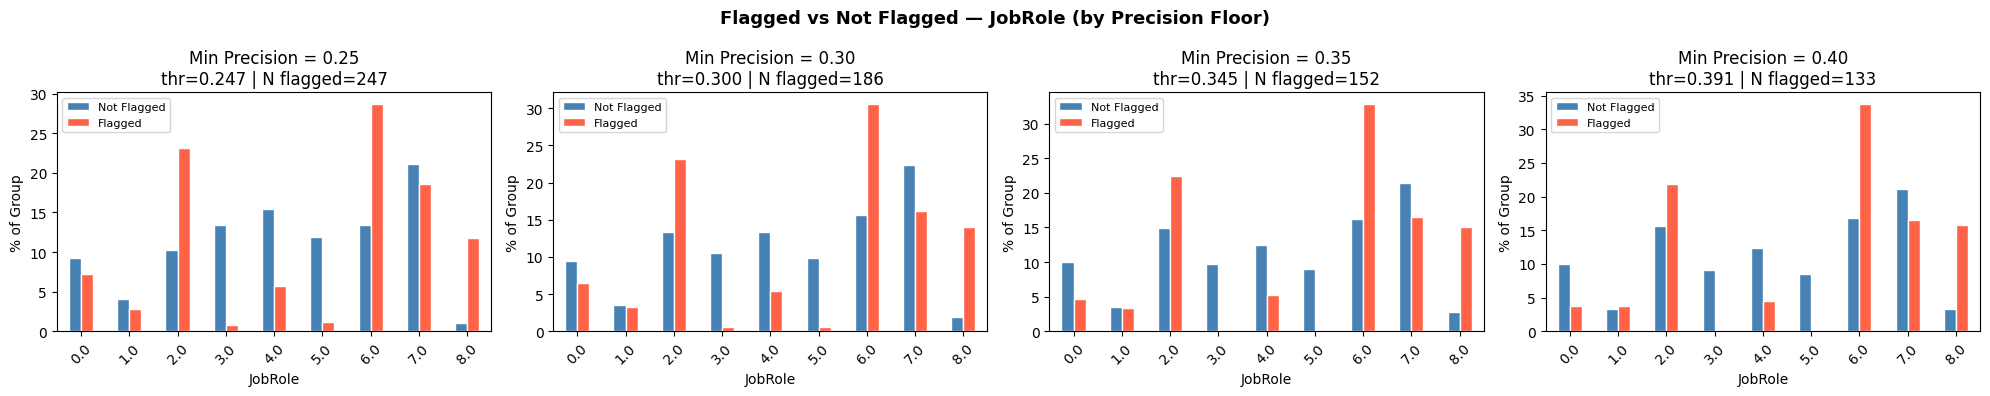

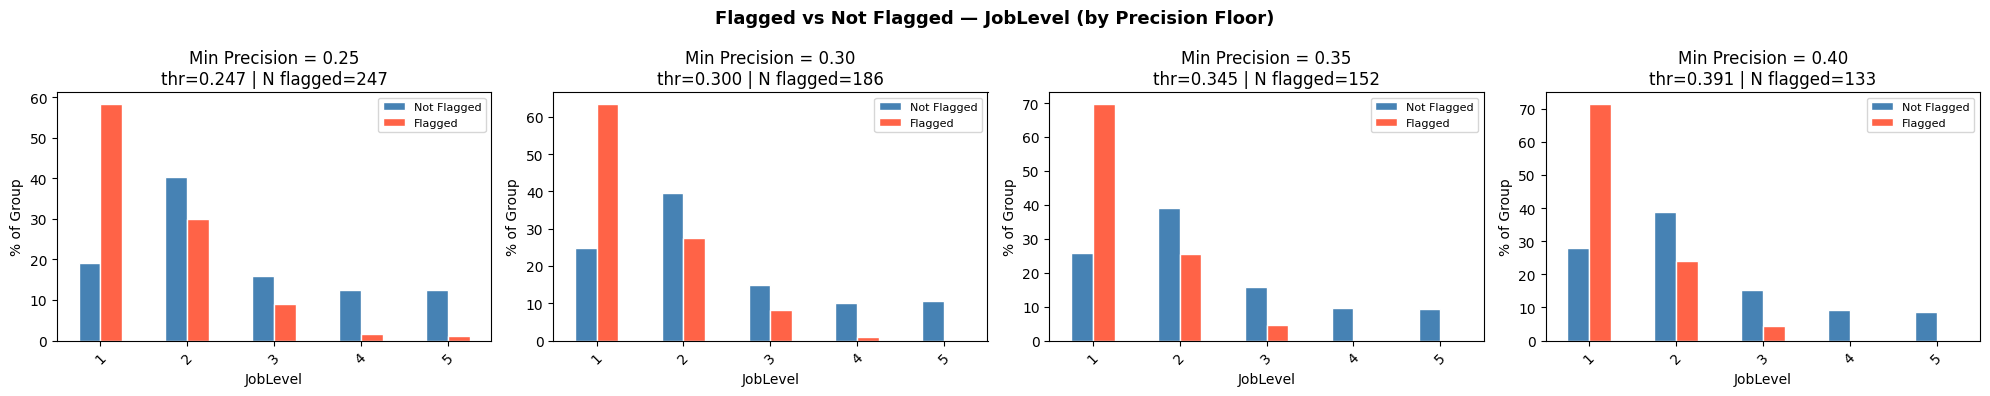

In [ ]:
# Step 2: Categorical features
for feat in categorical_features:
    if feat not in X_test.columns:
        print(f"Skipping {feat} — not found in test set columns")
        continue

    fig, axes = plt.subplots(
        1, len(precision_floors),
        figsize=(5 * len(precision_floors), 4),
        sharey=False
    )
    fig.suptitle(f"Flagged vs Not Flagged — {feat} (by Precision Floor)", fontsize=13, fontweight="bold")

    for ax, res in zip(axes, profiling_results):
        df = res["profile_df"]

        counts = df.groupby([feat, "Flagged"]).size().unstack(fill_value=0)
        counts.columns = ["Not Flagged", "Flagged"]

        # Normalize to proportions within each group
        counts_pct = counts.div(counts.sum(axis=0), axis=1) * 100
        counts_pct.plot(kind="bar", ax=ax, color=["steelblue", "tomato"], edgecolor="white")

        ax.set_title(f"Min Precision = {res['min_precision']:.2f}\n"
                     f"thr={res['threshold']:.3f} | N flagged={res['n_flagged']}")
        ax.set_xlabel(feat)
        ax.set_ylabel("% of Group")
        ax.tick_params(axis="x", rotation=45)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

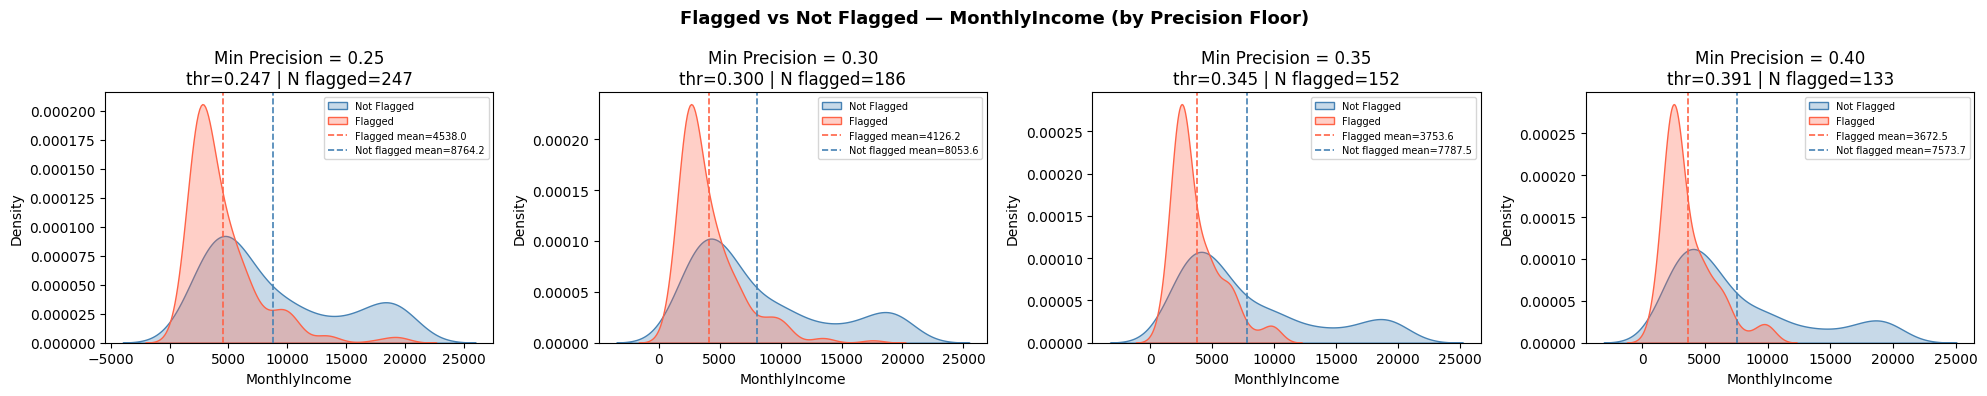

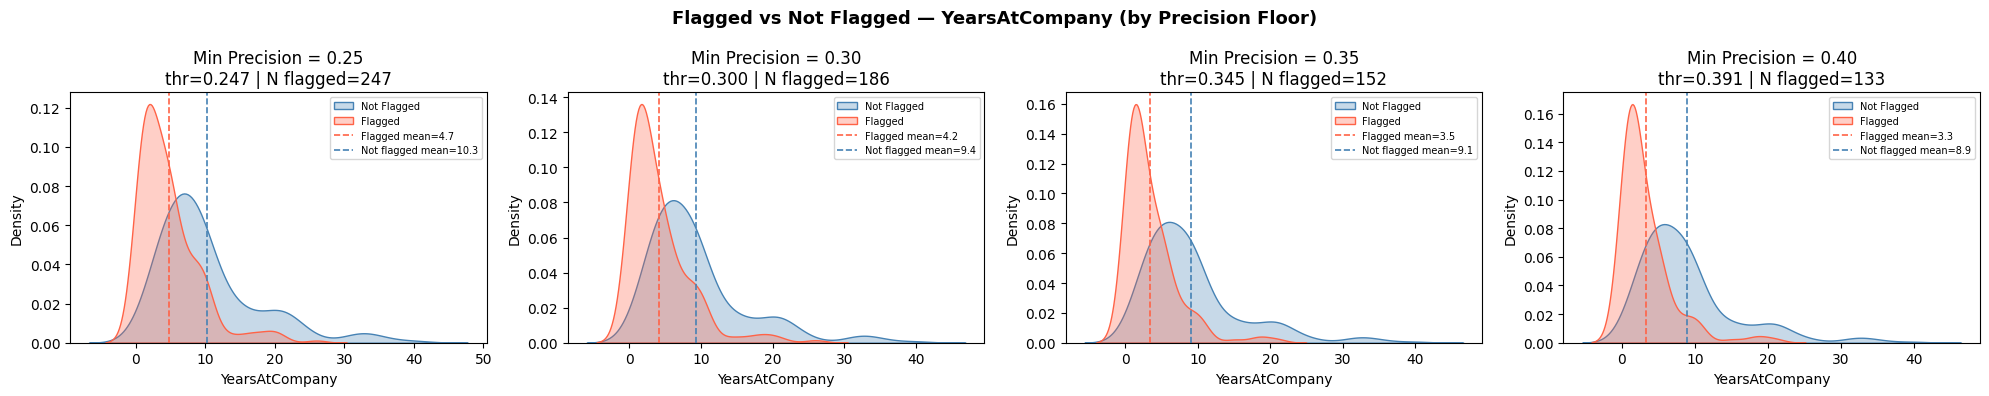

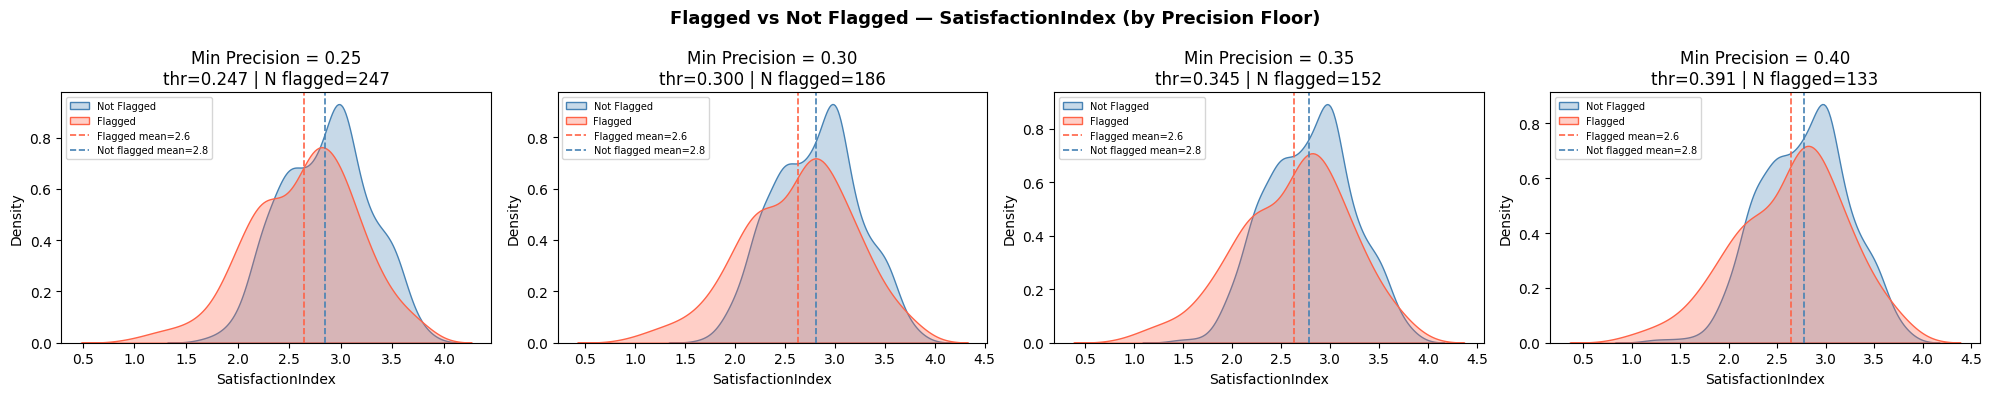

In [ ]:
# Step 3: Continuous features
for feat in continuous_features:
    if feat not in X_test.columns:
        print(f"Skipping {feat} — not found in test set columns")
        continue

    fig, axes = plt.subplots(
        1, len(precision_floors),
        figsize=(5 * len(precision_floors), 4),
        sharey=False
    )
    fig.suptitle(f"Flagged vs Not Flagged — {feat} (by Precision Floor)", fontsize=13, fontweight="bold")

    for ax, res in zip(axes, profiling_results):
        df = res["profile_df"]

        flagged_vals     = df.loc[df["Flagged"] == 1, feat].dropna()
        not_flagged_vals = df.loc[df["Flagged"] == 0, feat].dropna()

        sns.kdeplot(not_flagged_vals, ax=ax, label="Not Flagged", color="steelblue", fill=True, alpha=0.3)
        sns.kdeplot(flagged_vals,     ax=ax, label="Flagged",     color="tomato",    fill=True, alpha=0.3)

        ax.axvline(flagged_vals.mean(),     color="tomato",    linestyle="--", linewidth=1.2, label=f"Flagged mean={flagged_vals.mean():.1f}")
        ax.axvline(not_flagged_vals.mean(), color="steelblue", linestyle="--", linewidth=1.2, label=f"Not flagged mean={not_flagged_vals.mean():.1f}")

        ax.set_title(f"Min Precision = {res['min_precision']:.2f}\n"
                     f"thr={res['threshold']:.3f} | N flagged={res['n_flagged']}")
        ax.set_xlabel(feat)
        ax.set_ylabel("Density")
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

In [ ]:
# Step 4: Summary table — mean feature values by flagged group
print("\n=== Flagged Group Profile Summary (Test Set Means) ===\n")

for res in profiling_results:
    df = res["profile_df"]
    flagged_df     = df[df["Flagged"] == 1]
    not_flagged_df = df[df["Flagged"] == 0]

    summary = pd.DataFrame({
        "Flagged":     flagged_df[continuous_features].mean(),
        "Not Flagged": not_flagged_df[continuous_features].mean()
    }).round(3)

    print(f"Min Precision >= {res['min_precision']:.2f} | "
          f"Threshold = {res['threshold']:.3f} | "
          f"N Flagged = {res['n_flagged']}")
    print(summary.to_string())
    print()


=== Flagged Group Profile Summary (Test Set Means) ===

Min Precision >= 0.25 | Threshold = 0.247 | N Flagged = 247
                    Flagged  Not Flagged
MonthlyIncome      4538.008     8764.180
YearsAtCompany        4.713       10.299
SatisfactionIndex     2.645        2.849

Min Precision >= 0.30 | Threshold = 0.300 | N Flagged = 186
                    Flagged  Not Flagged
MonthlyIncome      4126.172     8053.612
YearsAtCompany        4.161        9.365
SatisfactionIndex     2.632        2.810

Min Precision >= 0.35 | Threshold = 0.345 | N Flagged = 152
                    Flagged  Not Flagged
MonthlyIncome      3753.579     7787.526
YearsAtCompany        3.461        9.121
SatisfactionIndex     2.628        2.791

Min Precision >= 0.40 | Threshold = 0.391 | N Flagged = 133
                    Flagged  Not Flagged
MonthlyIncome      3672.504     7573.688
YearsAtCompany        3.256        8.860
SatisfactionIndex     2.639        2.776



In [ ]:
# Final Threshold Selection: Precision-Constrained (min_precision=0.30)
chosen_threshold_rf = 0.300

#  Evaluate on Test Set
test_proba_rf = best_rf.predict_proba(X_test)[:, 1]
test_pred_rf  = (test_proba_rf >= chosen_threshold_rf).astype(int)

print(f"=== Random Forest @ Precision-Constrained Threshold (thr={chosen_threshold_rf}) ===\n")
print(f"Test ROC-AUC:               {roc_auc_score(y_test, test_proba_rf):.4f}")
print(f"Test PR-AUC:                {average_precision_score(y_test, test_proba_rf):.4f}")
print(f"Test Accuracy:              {accuracy_score(y_test, test_pred_rf):.4f}")
print(f"Test Precision (Attrition): {precision_score(y_test, test_pred_rf, zero_division=0):.4f}")
print(f"Test Recall (Attrition):    {recall_score(y_test, test_pred_rf, zero_division=0):.4f}")
print(f"Test F1 (Attrition):        {f1_score(y_test, test_pred_rf, zero_division=0):.4f}")

p_final = precision_score(y_test, test_pred_rf, zero_division=0)
r_final = recall_score(y_test, test_pred_rf, zero_division=0)
f2_final = (5 * p_final * r_final) / (4 * p_final + r_final + 1e-12)
print(f"Test F2 (Attrition):        {f2_final:.4f}")

print("\nConfusion Matrix (rows=true, cols=pred):")
print(confusion_matrix(y_test, test_pred_rf))

print("\nClassification Report:")
print(classification_report(
    y_test, test_pred_rf,
    target_names=["No Attrition", "Attrition"],
    zero_division=0
))

# --- Log to Results ---
record_results(
    results,
    model_name=f"Random Forest (Tuned, thr={chosen_threshold_rf})",
    model=best_rf,
    X_test=X_test,
    y_test=y_test,
    cv_auc=rf_grid.best_score_,
    threshold=chosen_threshold_rf,
    notes="Precision-constrained recall optimization, min_precision=0.30"
)

show_results(results)


=== Random Forest @ Precision-Constrained Threshold (thr=0.3) ===

Test ROC-AUC:               0.7557
Test PR-AUC:                0.3762
Test Accuracy:              0.6667
Test Precision (Attrition): 0.2957
Test Recall (Attrition):    0.7746
Test F1 (Attrition):        0.4280
Test F2 (Attrition):        0.5851

Confusion Matrix (rows=true, cols=pred):
[[239 131]
 [ 16  55]]

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.94      0.65      0.76       370
   Attrition       0.30      0.77      0.43        71

    accuracy                           0.67       441
   macro avg       0.62      0.71      0.60       441
weighted avg       0.83      0.67      0.71       441



,CV AUC,Test AUC,Accuracy,Attrition Precision,Attrition Recall,Attrition F1,Attrition F2,Notes
Model,,,,,,,,
Logistic Regression,0.831,0.818,0.712,0.325,0.732,0.450,0.586,"C=0.01, L2; heavy regularization suggests mult..."
Logistic Regression (thr=0.541),0.831,0.818,0.762,0.375,0.718,0.493,0.607,"C=0.01, L2; threshold optimized for F2 on OOF ..."
Decision Tree,0.736,0.677,0.667,0.268,0.620,0.374,0.491,"Best params: {'dt__criterion': 'gini', 'dt__ma..."
Decision Tree (thr=0.178),0.733,0.677,0.508,0.208,0.732,0.324,0.487,F2-optimized threshold
XGBoost,0.831,0.765,0.853,0.607,0.239,0.343,0.272,"Best params: {'subsample': 0.8, 'n_estimators'..."
XGBoost (thr=0.13300000131130219),0.831,0.765,0.773,0.382,0.662,0.485,0.577,F2-optimized threshold
Random Forest (Baseline),0.805,0.754,0.837,0.462,0.085,0.143,0.101,Default parameters
Random Forest (Tuned),0.821,0.756,0.805,0.391,0.380,0.386,0.382,"Best params: {'n_estimators': 100, 'min_sample..."
"Random Forest (Tuned, thr=0.3)",0.821,0.756,0.667,0.296,0.775,0.428,0.585,"Precision-constrained recall optimization, min..."


# Model Comparison & Final Model Selection

***The Business Context:***

Our goal isn't just maximizing accuracy or AUC - it's about catching employees who might leave. In HR retention, false positives (flagging someone who would have stayed) are relatively cheap - maybe a brief check-in conversation. But false negatives (missing someone who actually leaves) are expensive: recruitment costs, lost institutional knowledge, team disruption.


***Final Model Recommendation - F2 tuned Logistic Regression:***

Why Logistic Regression wins:
1. Highest recall among models without sacrificing interpretability - It catches 72% of attrition cases, exactly what we need for intervention targeting
2. Strong, stable AUC - 0.818 test AUC with minimal CV-test gap indicates robust generalization
3. Interpretability advantage - The coefficients directly tell us which factors increase/decrease attrition risk. We can say "a 1-unit increase in Overtime increases attrition log-odds by X" - this matters for HR stakeholders
4. Handling of multicollinearity - The heavy L2 regularization (C=0.01) automatically handles the correlated features we identified in EDA
5. Better precision-recall tradeoff - At equivalent recall (73%), logistic regression achieves higher precision (0.375 vs 0.289) and F2 (0.607 vs 0.414) than the tuned Random Forest

# Logistic Regression - Interpretability & Visualization

In [ ]:
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.inspection import permutation_importance
# SETUP AND DATA PREPARATION

# Retrieve our best logistic regression model from the grid search
# best_model was created during the logistic regression section
# If running this section separately, uncomment the lines below:
best_model = grid_search.best_estimator_

# Get feature names and ensure we have test data available
feature_names = X_train.columns
print("Setup complete. Model and data ready for interpretation.")
print(f"Number of features: {len(feature_names)}")
print(f"Test set size: {X_test.shape[0]} rows")


Setup complete. Model and data ready for interpretation.
Number of features: 49
Test set size: 441 rows


In [ ]:
# COEFFICIENT ANALYSIS
# Extract coefficients from the logistic regression model inside the pipeline
coefficients = best_model.named_steps['lr'].coef_[0]

# Create a clean dataframe for analysis
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
})

# Add odds ratios for easier business interpretation
# Odds ratio > 1 means the feature increases attrition risk
# Odds ratio < 1 means the feature decreases attrition risk
coef_df['odds_ratio'] = np.exp(coefficients)

# Sort by absolute coefficient magnitude to see the most influential features
coef_df = coef_df.sort_values('abs_coefficient', ascending=False)

# Display top features in console
print("\n" + "="*60)
print("TOP 20 FEATURES BY COEFFICIENT MAGNITUDE")
print("="*60)
print(coef_df.head(20)[['feature', 'coefficient', 'odds_ratio']].to_string())


TOP 20 FEATURES BY COEFFICIENT MAGNITUDE
                    feature  coefficient  odds_ratio
29               isOverTime     0.317911    1.374253
33   CareerMobilityProxyLog     0.215597    1.240603
1            BusinessTravel     0.196604    1.217262
13            MaritalStatus     0.174557    1.190719
3                Department     0.166025    1.180602
36        SatisfactionIndex    -0.165445    0.847516
9            JobInvolvement    -0.165160    0.847758
39            CommuteBurden     0.151009    1.163007
0                       Age    -0.140143    0.869234
30     PromotionVelocityLog    -0.137310    0.871700
20         StockOptionLevel    -0.136974    0.871993
26  YearsSinceLastPromotion     0.135828    1.145484
37     SatisfactionVariance     0.134159    1.143574
35        IncomePerJobLevel    -0.132784    0.875654
38      MinimumSatisfaction    -0.132437    0.875958
31          RoleTenureRatio    -0.113073    0.893085
16       NumCompaniesWorked     0.110756    1.117122
7   

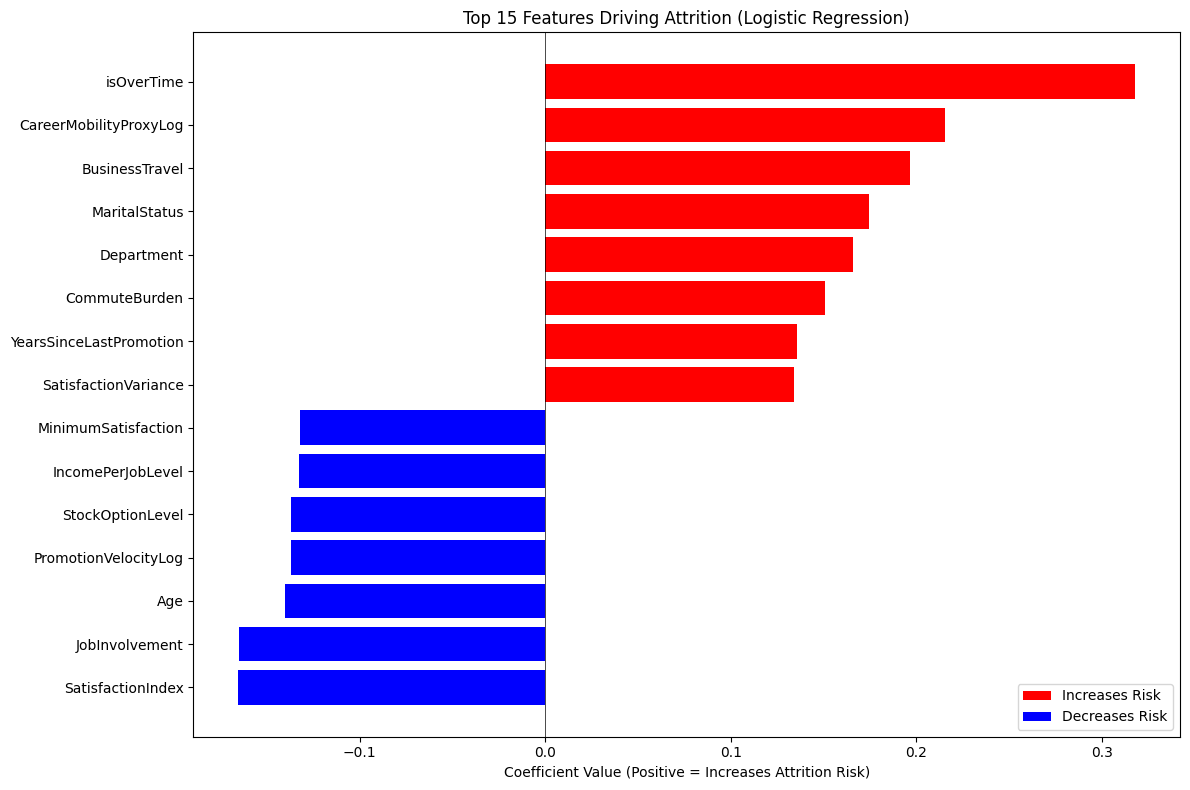

In [ ]:
# VISUALIZE TOP COEFFICIENTS

plt.figure(figsize=(12, 8))
top_n = 15
top_coefs = coef_df.head(top_n).copy()

# Sort for better visualization (descending within the plot)
top_coefs = top_coefs.sort_values('coefficient', ascending=True)

# Color code: red for positive (increases attrition), blue for negative (decreases)
colors = ['red' if c > 0 else 'blue' for c in top_coefs['coefficient']]

plt.barh(range(top_n), top_coefs['coefficient'], color=colors)
plt.yticks(range(top_n), top_coefs['feature'])
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Coefficient Value (Positive = Increases Attrition Risk)')
plt.title(f'Top {top_n} Features Driving Attrition (Logistic Regression)')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='Increases Risk'),
                   Patch(facecolor='blue', label='Decreases Risk')]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()


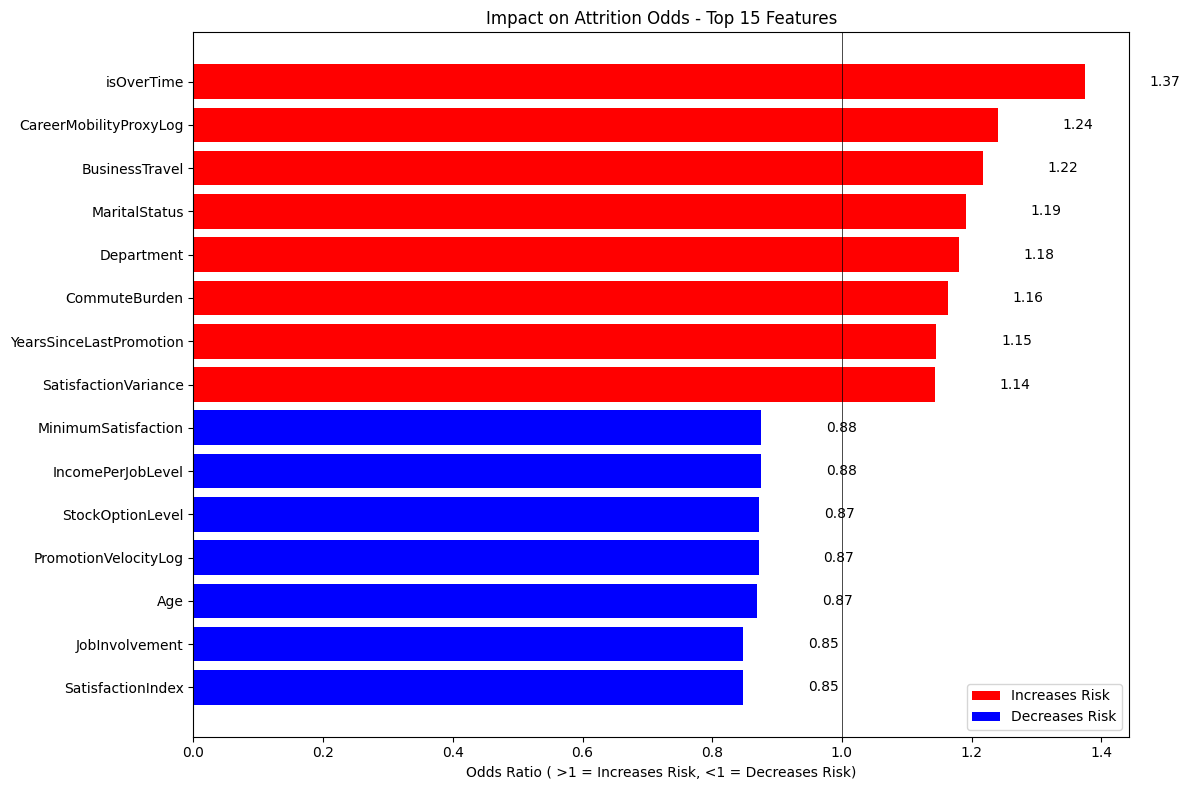

In [ ]:
# ODDS RATIO PLOT

plt.figure(figsize=(12, 8))
odds_plot = coef_df.head(15).copy()
odds_plot = odds_plot.sort_values('odds_ratio', ascending=True)

# For odds ratios, values > 1 increase risk, < 1 decrease risk
colors = ['red' if or_val > 1 else 'blue' for or_val in odds_plot['odds_ratio']]

# Create horizontal bar chart for odds ratios
bars = plt.barh(range(15), odds_plot['odds_ratio'], color=colors)
plt.yticks(range(15), odds_plot['feature'])
plt.axvline(x=1, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Odds Ratio ( >1 = Increases Risk, <1 = Decreases Risk)')
plt.title('Impact on Attrition Odds - Top 15 Features')

for i, (bar, val) in enumerate(zip(bars, odds_plot['odds_ratio'])):
    plt.text(val + 0.1, i, f'{val:.2f}', va='center')

legend_elements = [Patch(facecolor='red', label='Increases Risk'),
                   Patch(facecolor='blue', label='Decreases Risk')]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()


In [ ]:
# CORRECTED SHAP ANALYSIS FOR LOGISTIC REGRESSION

# Isolate the logistic regression model and scaler from the pipeline
lr_model = best_model.named_steps['lr']
scaler = best_model.named_steps['scaler']

# Scale the test data
X_test_scaled = scaler.transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_names)

# IMPORTANT: For logistic regression, we need to work with log-odds, not probabilities

# Create explainer without feature_perturbation (let it use default)
explainer_lr = shap.LinearExplainer(lr_model, X_test_scaled_df)

# Get SHAP values in log-odds space
shap_values_lr = explainer_lr.shap_values(X_test_scaled_df)

print("\n" + "="*60)
print("SHAP ANALYSIS COMPLETE (LOG-ODDS SPACE)")
print("="*60)
print(f"SHAP values shape: {shap_values_lr.shape}")
print(f"Expected value (baseline log-odds): {explainer_lr.expected_value:.4f}")

# VERIFICATION: Check first prediction in log-odds space
# Get log-odds from model
first_pred_log_odds = lr_model.decision_function(X_test_scaled_df.iloc[:1])[0]
first_shap_sum = explainer_lr.expected_value + shap_values_lr[0].sum()

print(f"\nVERIFICATION IN LOG-ODDS SPACE:")
print(f"First prediction log-odds: {first_pred_log_odds:.4f}")
print(f"Expected value + SHAP sum: {first_shap_sum:.4f}")
print(f"Match in log-odds: {abs(first_pred_log_odds - first_shap_sum) < 1e-10}")

# Convert to probabilities for interpretation
import scipy.special
first_pred_prob = scipy.special.expit(first_pred_log_odds)
print(f"\nCorresponding probability: {first_pred_prob:.4f}")


SHAP ANALYSIS COMPLETE (LOG-ODDS SPACE)
SHAP values shape: (441, 49)
Expected value (baseline log-odds): -0.5010

VERIFICATION IN LOG-ODDS SPACE:
First prediction log-odds: 0.6244
Expected value + SHAP sum: 0.6244
Match in log-odds: True

Corresponding probability: 0.6512


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


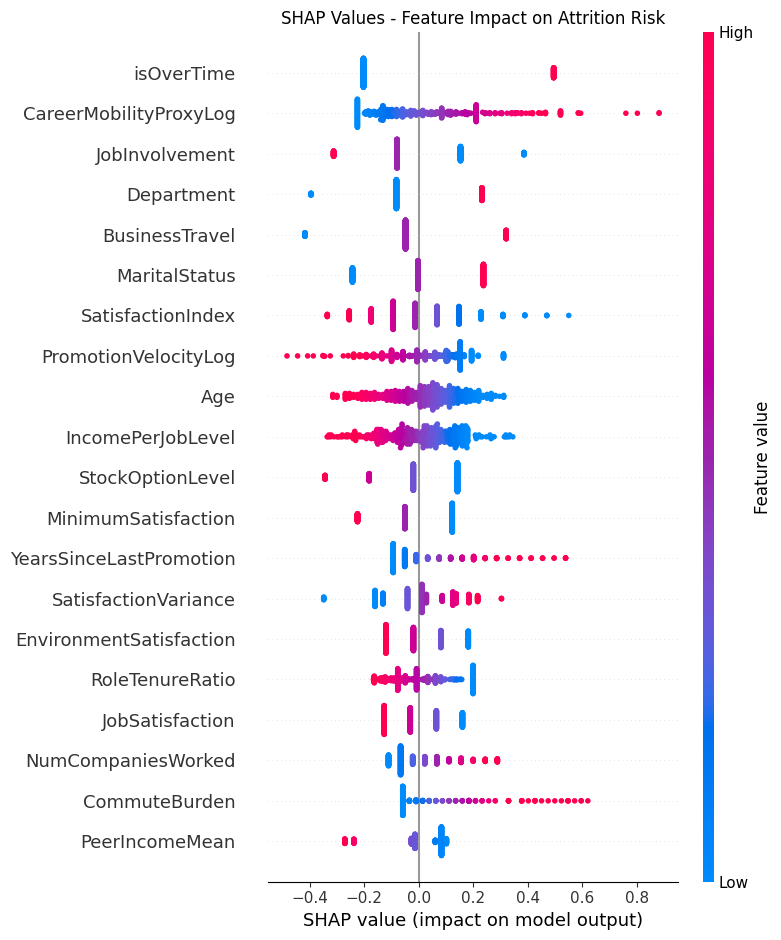

In [ ]:
# SHAP SUMMARY PLOT
# This shows the distribution of SHAP values for each feature
# It reveals both the direction and magnitude of impacts across all employees

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_lr,
    X_test_scaled_df,
    feature_names=feature_names,
    plot_type="dot",
    show=False
)
plt.title('SHAP Values - Feature Impact on Attrition Risk')
plt.tight_layout()
plt.show()

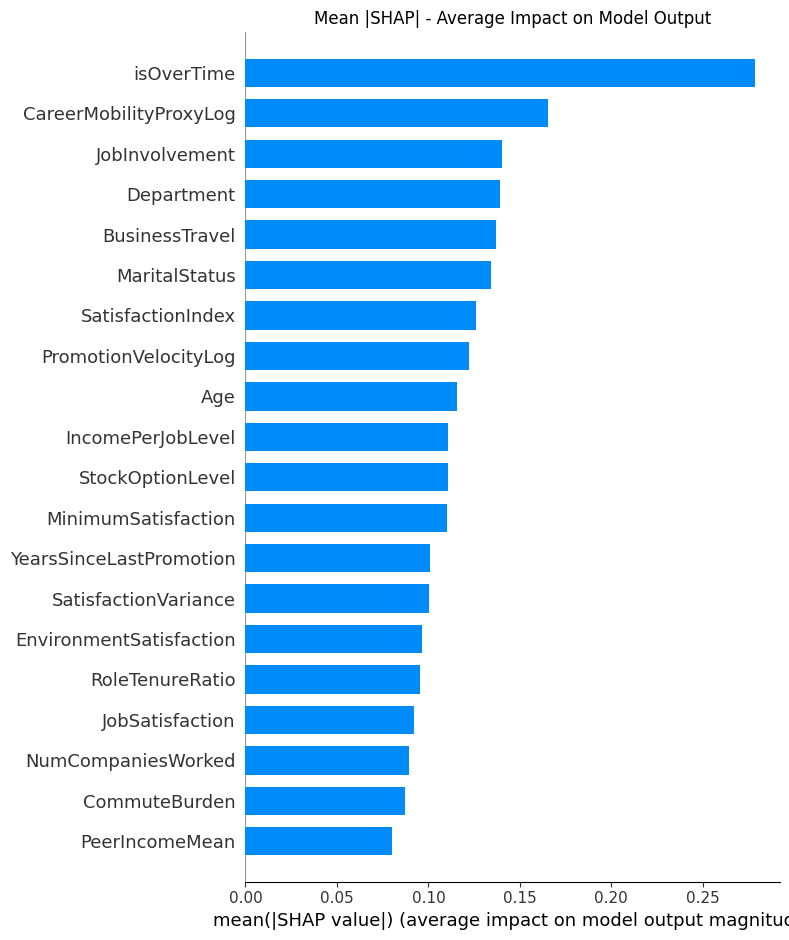

In [ ]:
# SHAP BAR PLOT (MEAN ABSOLUTE SHAP)
# This shows global feature importance - which features matter most on average

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_lr,
    X_test_scaled_df,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.title('Mean |SHAP| - Average Impact on Model Output')
plt.tight_layout()
plt.show()

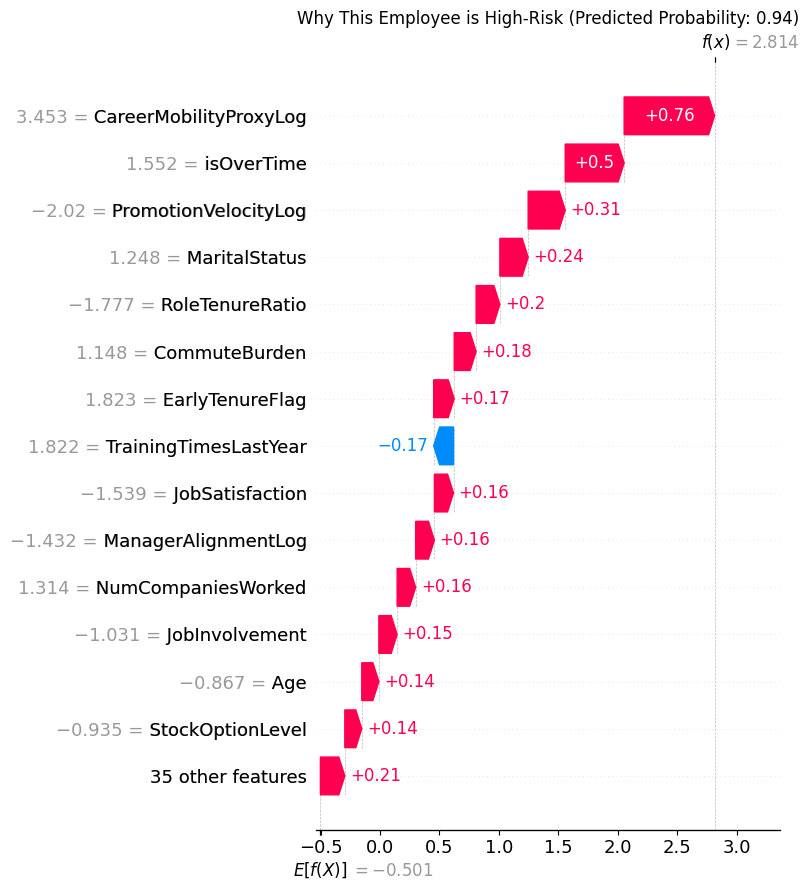


HIGH-RISK EMPLOYEE PROFILE
This employee's key characteristics:
  isOverTime: 1.0
  CareerMobilityProxyLog: 0.9162907318741552
  BusinessTravel: 1.0
  MaritalStatus: 2.0
  Department: 1.0
  SatisfactionIndex: 2.75
  JobInvolvement: 2.0
  CommuteBurden: 10.0
  Age: 29.0
  PromotionVelocityLog: 0.0


In [ ]:
# SHAP WATERFALL PLOT - EXPLAIN A SINGLE PREDICTION
# This is extremely useful for HR to understand why a specific employee is at risk

# Find a high-risk employee (top 5% highest predicted probability)
pred_probs = best_model.predict_proba(X_test)[:, 1]
high_risk_idx = np.argsort(pred_probs)[-5:]  # Top 5 highest risk

# Pick one example for detailed explanation
example_idx = high_risk_idx[2]  # Choose one of the high-risk employees

plt.figure(figsize=(14, 8))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_lr[example_idx],
        base_values=explainer_lr.expected_value,
        data=X_test_scaled_df.iloc[example_idx].values,
        feature_names=feature_names
    ),
    show=False,
    max_display=15
)
plt.title(f'Why This Employee is High-Risk (Predicted Probability: {pred_probs[example_idx]:.2f})')
plt.tight_layout()
plt.show()

# Print actual feature values for this high-risk employee
print("\n" + "="*60)
print("HIGH-RISK EMPLOYEE PROFILE")
print("="*60)
print("This employee's key characteristics:")
high_risk_employee = X_test.iloc[example_idx]
for feature in coef_df.head(10)['feature'].values:
    if feature in high_risk_employee.index:
        print(f"  {feature}: {high_risk_employee[feature]}")

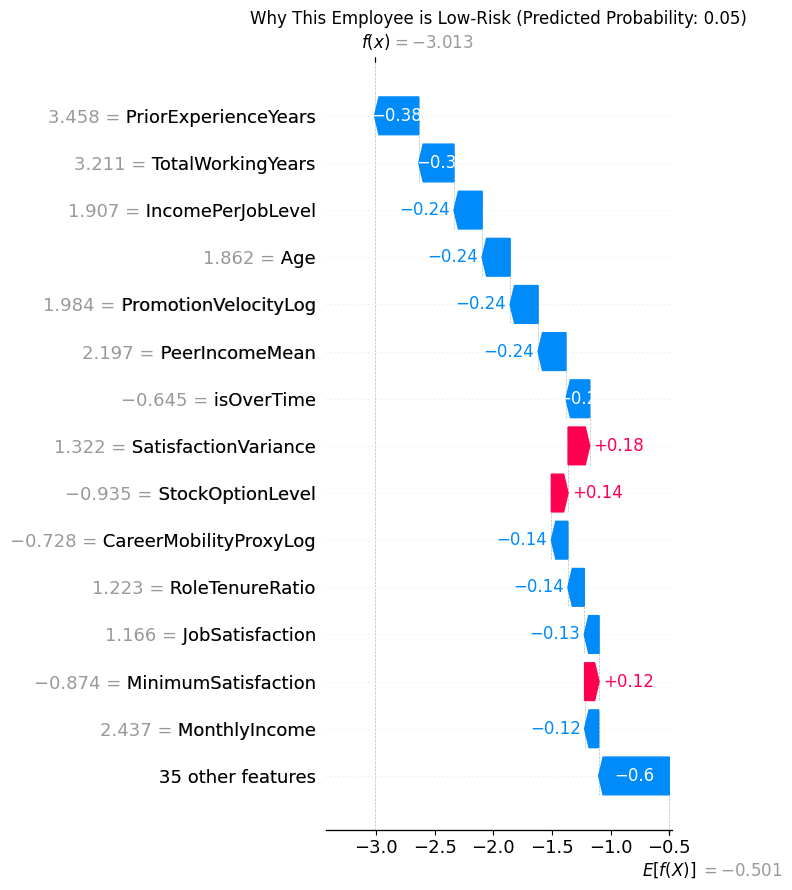

In [ ]:
# FIND A LOW-RISK EMPLOYEE FOR COMPARISON
# Compare with a low-risk employee to highlight contrasts

low_risk_idx = np.argsort(pred_probs)[:5][0]  # One of the lowest risk

plt.figure(figsize=(14, 8))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_lr[low_risk_idx],
        base_values=explainer_lr.expected_value,
        data=X_test_scaled_df.iloc[low_risk_idx].values,
        feature_names=feature_names
    ),
    show=False,
    max_display=15
)
plt.title(f'Why This Employee is Low-Risk (Predicted Probability: {pred_probs[low_risk_idx]:.2f})')
plt.tight_layout()
plt.show()


CALCULATING PERMUTATION IMPORTANCE
This may take a minute...

TOP 15 FEATURES BY PERMUTATION IMPORTANCE:
                    feature  importance       std
29               isOverTime    0.047035  0.007290
39            CommuteBurden    0.016075  0.003717
1            BusinessTravel    0.014168  0.004949
13            MaritalStatus    0.013711  0.003116
9            JobInvolvement    0.010301  0.004409
26  YearsSinceLastPromotion    0.010122  0.003567
38      MinimumSatisfaction    0.008455  0.003765
12          JobSatisfaction    0.007625  0.001815
36        SatisfactionIndex    0.006570  0.002298
37     SatisfactionVariance    0.005961  0.004614
28                 isFemale    0.005790  0.002175
48            IncomeVsPeers    0.005017  0.003062
22    TrainingTimesLastYear    0.004694  0.002722
7   EnvironmentSatisfaction    0.003947  0.002317
31          RoleTenureRatio    0.003871  0.002403


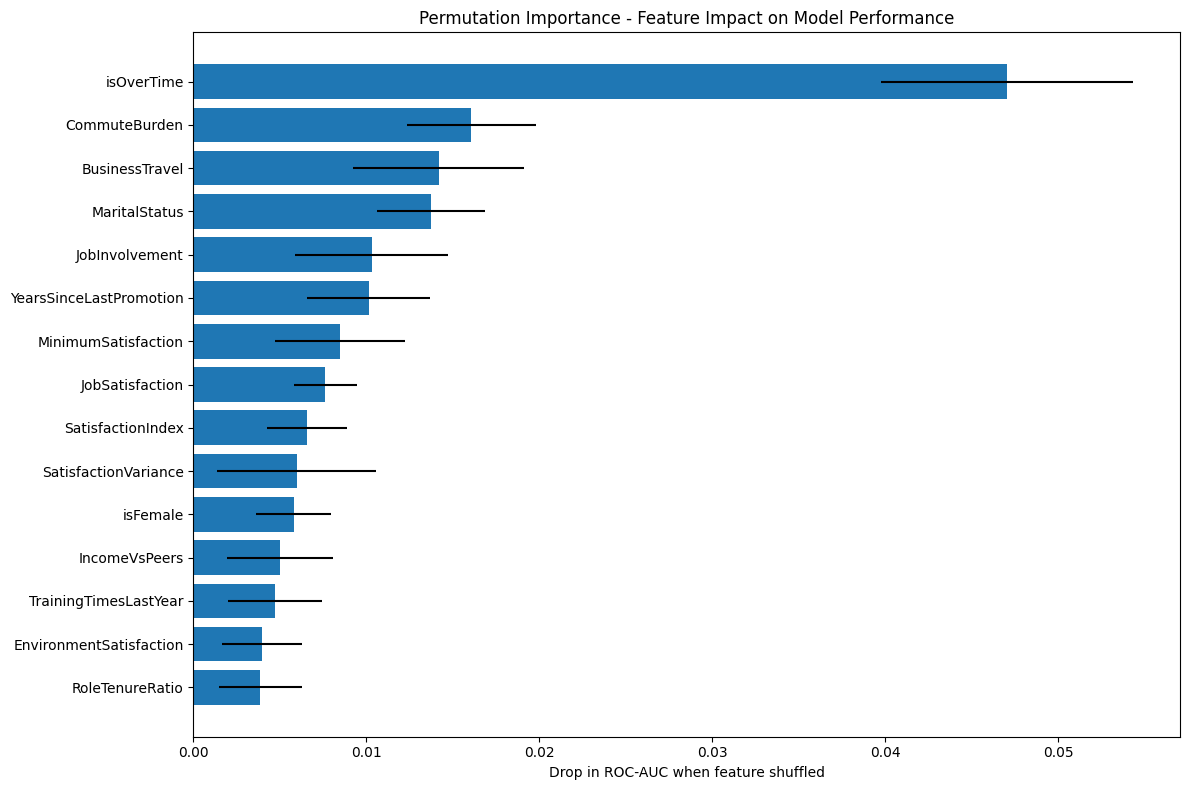

In [ ]:
# PERMUTATION IMPORTANCE (MODEL-AGNOSTIC VALIDATION)
# This provides an alternative view of feature importance
# It measures how much model performance drops when we shuffle each feature

print("\n" + "="*60)
print("CALCULATING PERMUTATION IMPORTANCE")
print("="*60)
print("This may take a minute...")

perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc',
    n_jobs=-1
)

# Create importance dataframe
perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

# Display top features by permutation importance
print("\nTOP 15 FEATURES BY PERMUTATION IMPORTANCE:")
print(perm_df.head(15)[['feature', 'importance', 'std']].to_string())

# Plot permutation importance
plt.figure(figsize=(12, 8))
top_perm = perm_df.head(15).copy()
top_perm = top_perm.sort_values('importance', ascending=True)  # For horizontal plot

plt.barh(range(15), top_perm['importance'], xerr=top_perm['std'])
plt.yticks(range(15), top_perm['feature'])
plt.xlabel('Drop in ROC-AUC when feature shuffled')
plt.title('Permutation Importance - Feature Impact on Model Performance')
plt.tight_layout()
plt.show()


In [ ]:
# HR-FRIENDLY SUMMARY TABLE

# Create a summary table with business-friendly interpretations
summary_table = coef_df.head(20).copy()
summary_table['impact_direction'] = summary_table['coefficient'].apply(
    lambda x: 'Increases Risk' if x > 0 else 'Decreases Risk'
)
summary_table['percent_impact'] = summary_table['odds_ratio'].apply(
    lambda x: f"{((x-1)*100):.0f}%" if x > 1 else f"{((1-x)*100):.0f}%"
)

summary_table['business_interpretation'] = summary_table.apply(
    lambda row: f"{row['feature']} has a {row['impact_direction'].lower()} effect. "
                f"A one-unit increase {row['impact_direction'].lower()} odds by {row['percent_impact']}.",
    axis=1
)

print("\n" + "="*60)
print("TOP 20 ATTRITION DRIVERS - HR SUMMARY")
print("="*60)
print(summary_table[['feature', 'odds_ratio', 'impact_direction', 'percent_impact', 'business_interpretation']].to_string())


TOP 20 ATTRITION DRIVERS - HR SUMMARY
                    feature  odds_ratio impact_direction percent_impact                                                                               business_interpretation
29               isOverTime    1.374253   Increases Risk            37%               isOverTime has a increases risk effect. A one-unit increase increases risk odds by 37%.
33   CareerMobilityProxyLog    1.240603   Increases Risk            24%   CareerMobilityProxyLog has a increases risk effect. A one-unit increase increases risk odds by 24%.
1            BusinessTravel    1.217262   Increases Risk            22%           BusinessTravel has a increases risk effect. A one-unit increase increases risk odds by 22%.
13            MaritalStatus    1.190719   Increases Risk            19%            MaritalStatus has a increases risk effect. A one-unit increase increases risk odds by 19%.
3                Department    1.180602   Increases Risk            18%               Depar

# Final Notes & Extensions

## 1. Why ROC-AUC and F2 as Optimization Metrics

**ROC-AUC** measures how well the model *ranks* positive cases (churners) above negative ones across *all* classification thresholds — it's threshold-agnostic, so it tells you about the model's fundamental discriminative ability rather than performance at any one cutoff. It's especially useful when class imbalance is present (as in attrition datasets), since raw accuracy would be misleading.

CN: We would also not use raw accuracy for reproducibility. With only ~16% of employees leaving in our data, we could achieve 84% accuracy by just predicting no one leaving, which wouldn't be informative or helpful for future HR decisions. With ROC-AUC, the model would actually learn to find the people leaving and inform future decision-making.

**F2** is a weighted harmonic mean of precision and recall that *deliberately tilts toward recall* (β=2 means recall is weighted twice as heavily as precision). In attrition, a **false negative** (missing an employee who leaves) is far more costly than a **false positive** (flagging someone who stays) — you lose a whole employee vs. spending some retention resources unnecessarily. F2 formalizes that asymmetry directly into the optimization target.

CN: F2 (β=2) directly bakes in our business priorities, with an acceptable tradeoff of identifying 2 leavers as worth the cost of 1 extra false alarm.

---

## 2. Why Train/Test Differences Are Acceptable

The gaps in accuracy, precision, and recall across train and test sets are expected and not alarming because:

- **We're not optimizing for those metrics** — we optimized for F2 and ROC-AUC, so some slippage in the others is natural.
- **Some train/test gap is normal** generalization behavior and only becomes a problem if it's extreme.
- **The direction of the gap is interpretable** — models that are slightly more aggressive on training data will naturally tighten up on unseen data.

As long as test performance is still *useful* (not random) and ROC-AUC holds up on the test set, the model is doing its job.

---

## 3. Framing Next Steps via Dollar Impact

The bridge from model output to business action runs through **cost-benefit framing**:

- Each **true positive** (correctly flagged leaver) represents a retention opportunity worth ~\$X — typically estimated as a multiple of salary (often 50–200% depending on role).
- Each **false positive** costs ~\$Y in retention resources spent unnecessarily.

By sweeping across classification thresholds, we can identify the **threshold that maximizes expected net value** rather than just F2. This reframes the model from an academic exercise into a decision tool — leadership can then ask *"at our current attrition rate and retention budget, what threshold should we use?"* rather than *"which model has the best metric?"*



---



**[Brainstorming] How Threshold Tuning Connects to P&L**

**The Core Logic: **
Every classification decision your model makes has a dollar consequence. There are four possible outcomes and each maps to a cost or saving:

A true positive is an employee flagged as a flight risk who actually leaves.

1.   A true positive is an employee flagged as a flight risk who actually leaves. This is a retention opportunity. If HR intervenes successfully, you save the replacement cost. If the intervention fails, you still spent intervention cost but saved nothing.

2.   A false positive is an employee flagged as a flight risk who would have stayed anyway. This is a wasted intervention cost.


3.   A false negative is an employee who leaves but was never flagged. This is the most expensive outcome. Full replacement cost with no opportunity to intervene.

4.   A true negative is an employee correctly identified as low risk. This has no direct cost.




---



**Threshold tuning = cost-benefit optimization**

At any given threshold you can compute the expected net value of each scenario. For example:

*   Expected savings = (number of true positives) × (replacement cost) × (intervention success rate)

*   Expected cost = (number of true positives + false positives) × (intervention cost)


*   Net value = Expected savings minus expected cost


As you lower the threshold you catch more true positives (higher recall) but also flag more false positives (lower precision). The optimal threshold from a P&L perspective is where the marginal cost of one additional false positive equals the marginal expected saving from one additional true positive caught.

For example, we can write something like:

At your chosen threshold of 0.30 with recall of 0.775, if your test set is representative of a company with say 1,000 employees and 16 percent annual attrition, that means roughly 160 employees will leave per year. Your model at 0.775 recall catches about 124 of them before they leave. If even half of those interventions succeed at a conservative replacement cost of 50,000 per employee, that is 62 retained employees times 50,000 equals 3.1 million in avoided replacement costs annually. Against an intervention budget of 186 flagged employees times 3,000 per intervention equals 558,000, the net value is roughly 2.5 million per year.